In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.utils import resample
from joblib import Parallel, delayed
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold


import time


# [1]: Make_blobs(blablabla) = df1

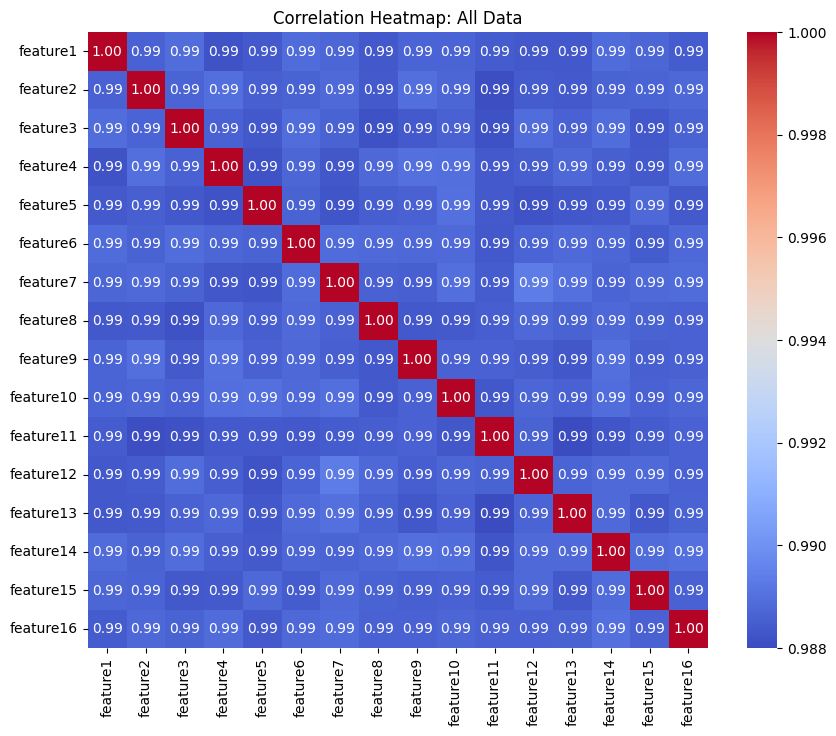

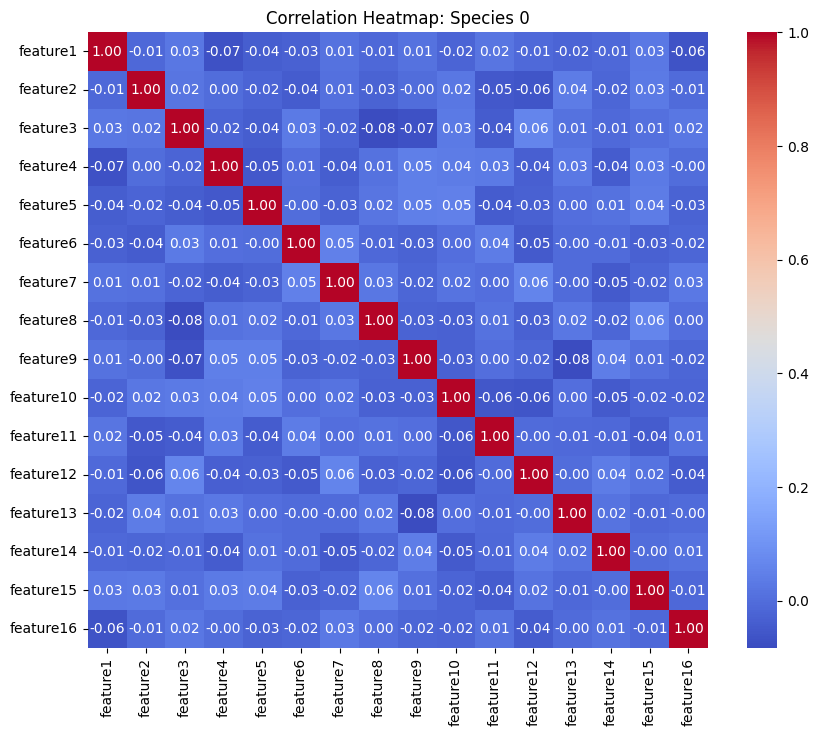

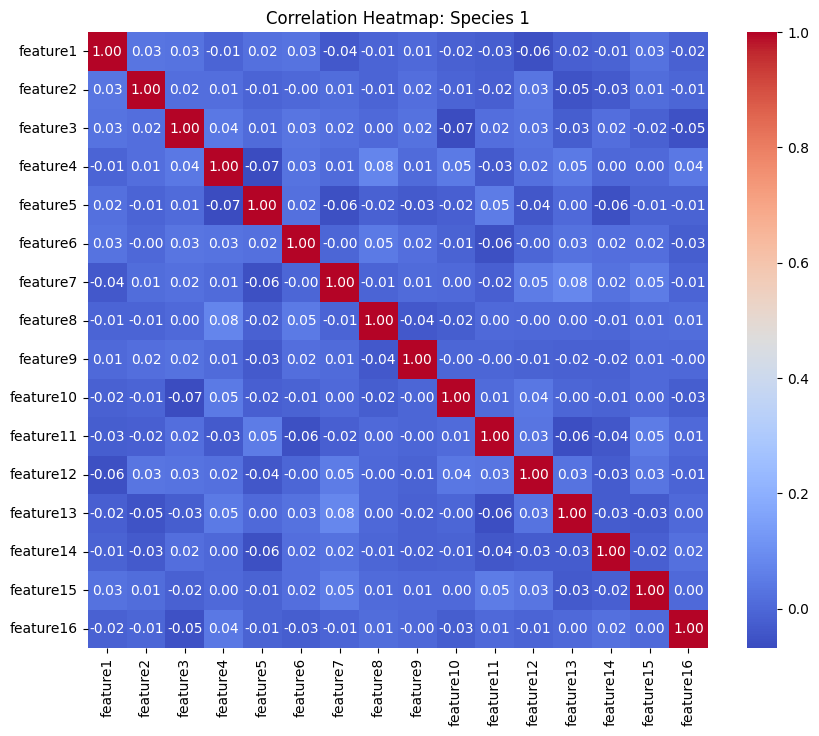

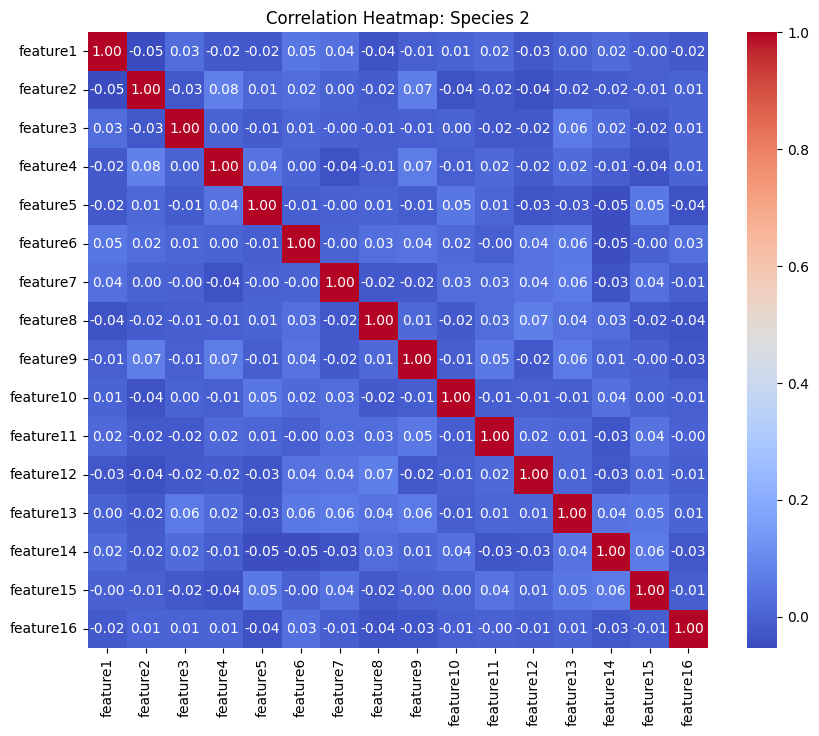

In [35]:
# === Данные ===
n_samples = 1000
n_features = 16
centers = np.array([
    np.zeros(n_features),
    np.ones(n_features) * 0.5,
    np.ones(n_features) * 20
])

x, y = make_blobs(
    n_samples=[n_samples, n_samples, n_samples],
    centers=centers,
    n_features=n_features,
    cluster_std=[1.0, 1.0, 1.0],
    random_state=42
)

feature_names = [f'feature{i+1}' for i in range(n_features)]
df1 = pd.DataFrame(x, columns=feature_names)
df1['species'] = y

# === Корреляции по всему датасету ===
plt.figure(figsize=(10, 8))
corr_all = df1[feature_names].corr()
sns.heatmap(corr_all, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap: All Data")
plt.show()

# === Корреляции по каждому классу ===
for cls in df1['species'].unique():
    plt.figure(figsize=(10, 8))
    corr_cls = df1[df1['species'] == cls][feature_names].corr()
    sns.heatmap(corr_cls, annot=True, fmt=".2f", cmap="coolwarm")
    plt.title(f"Correlation Heatmap: Species {cls}")
    plt.show()

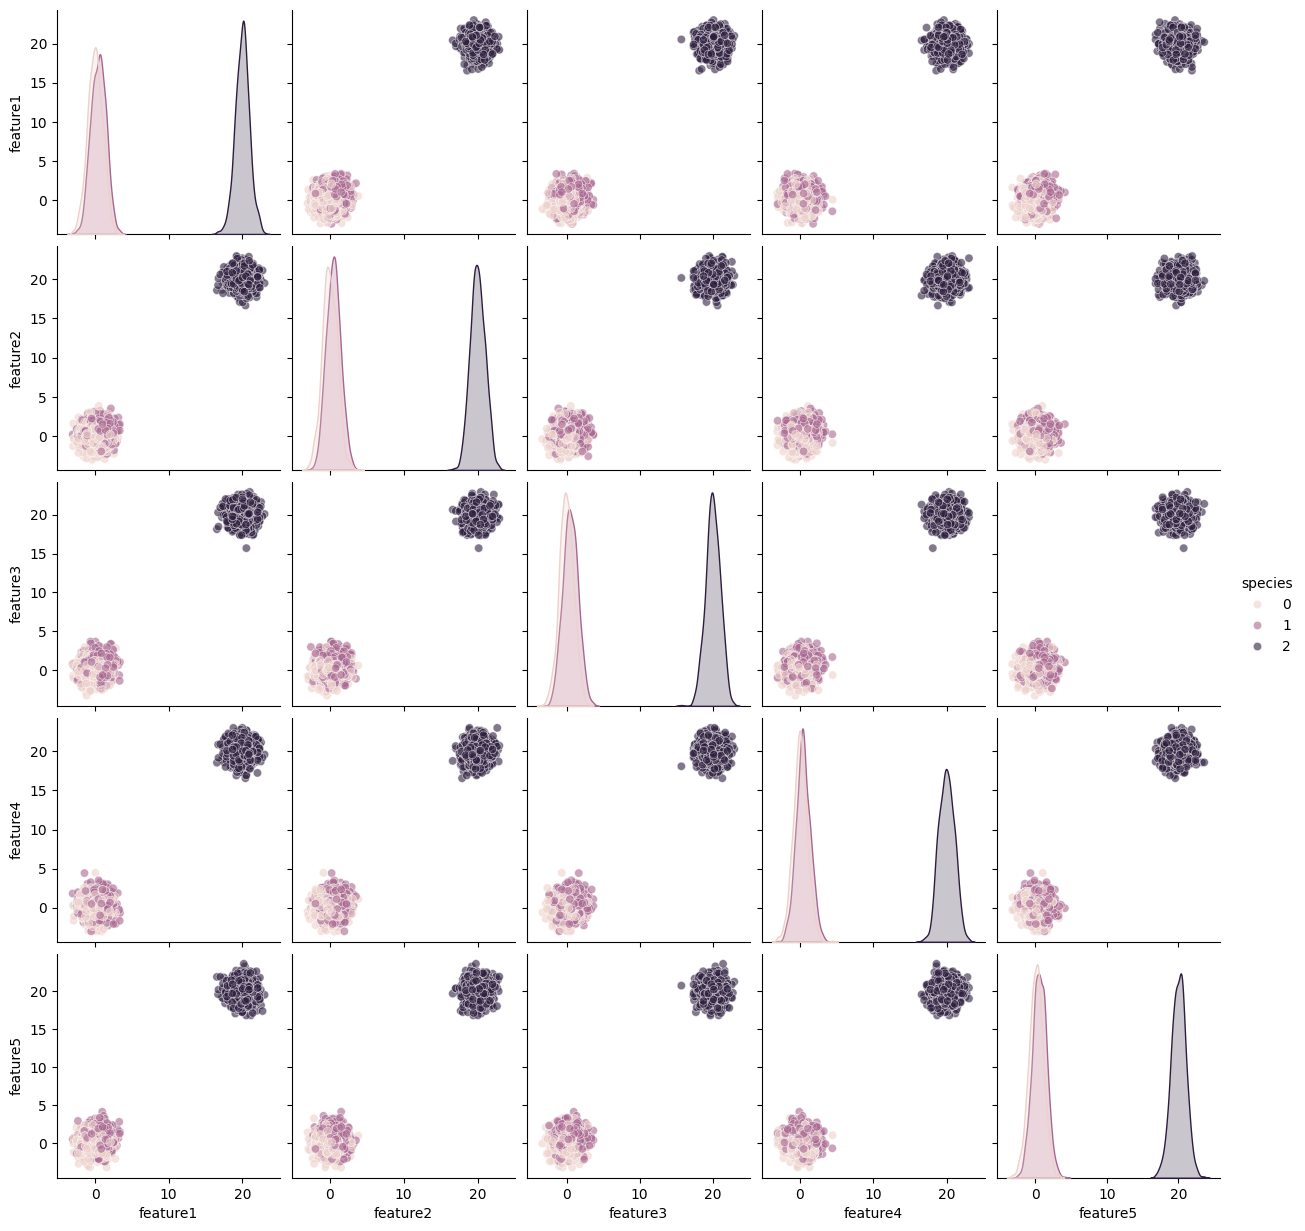

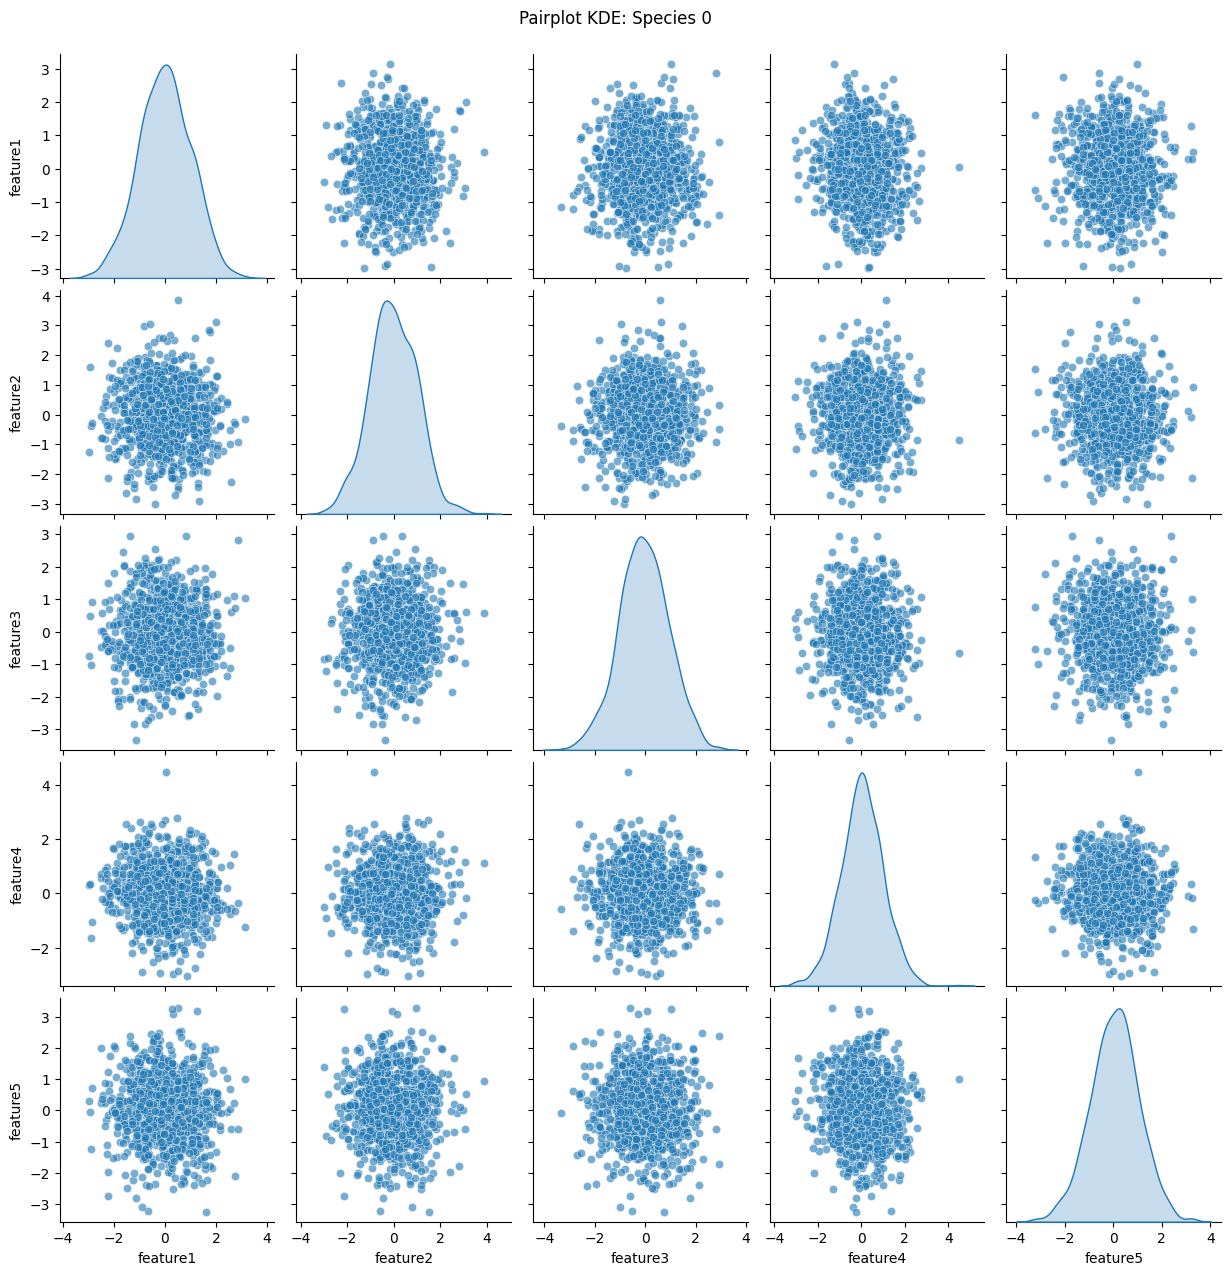

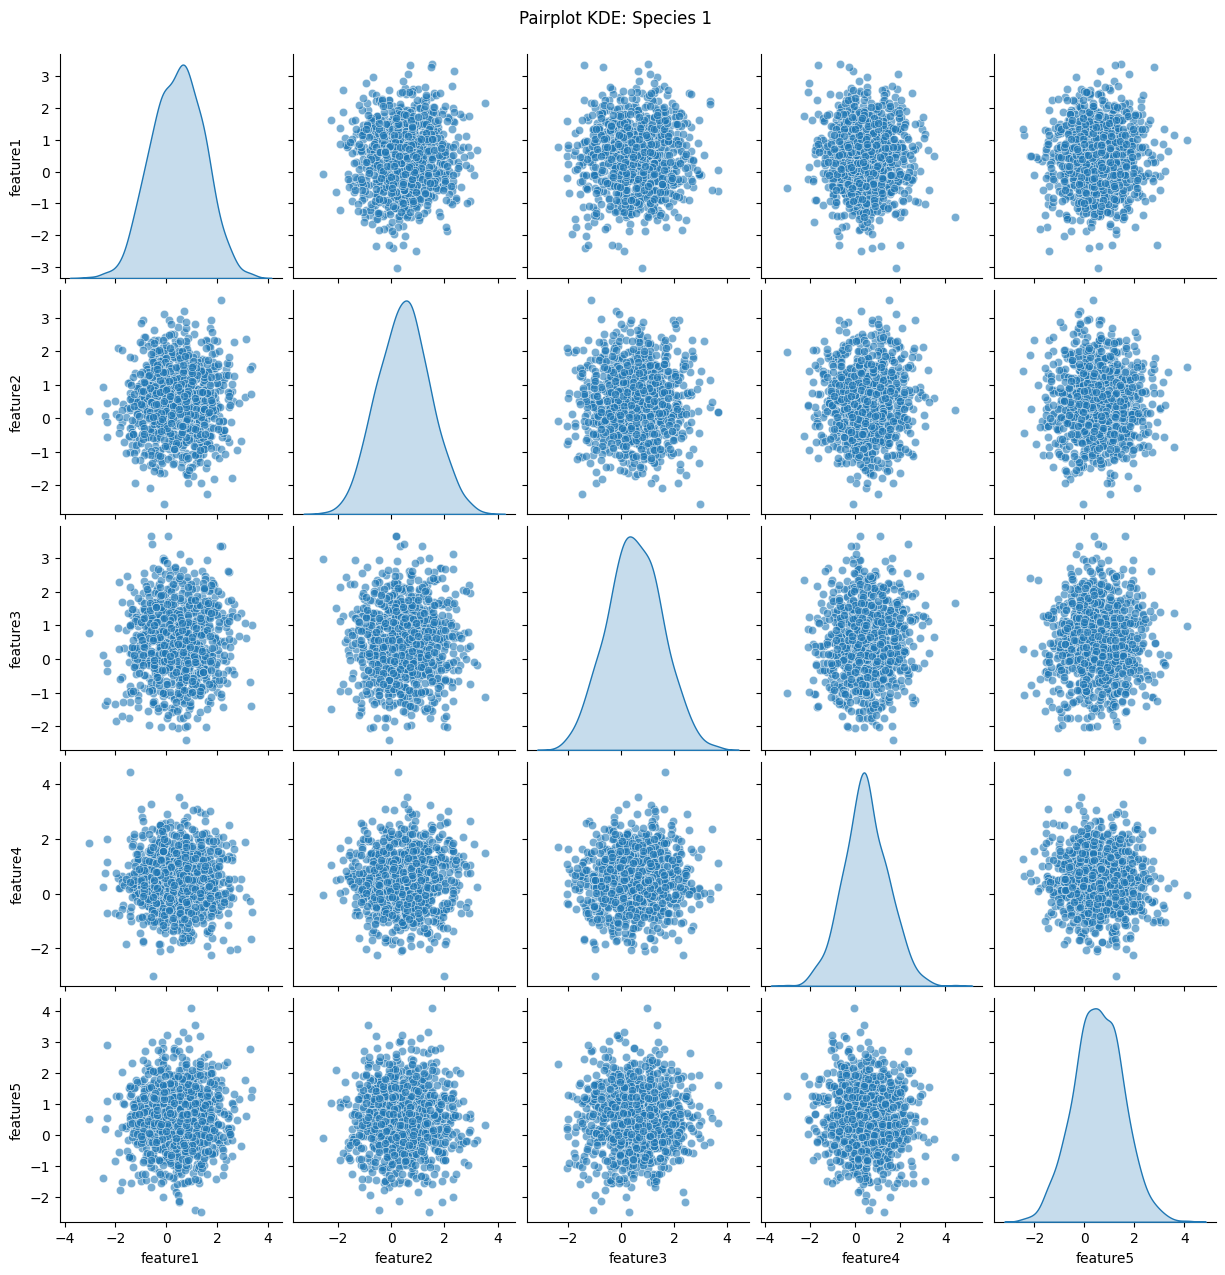

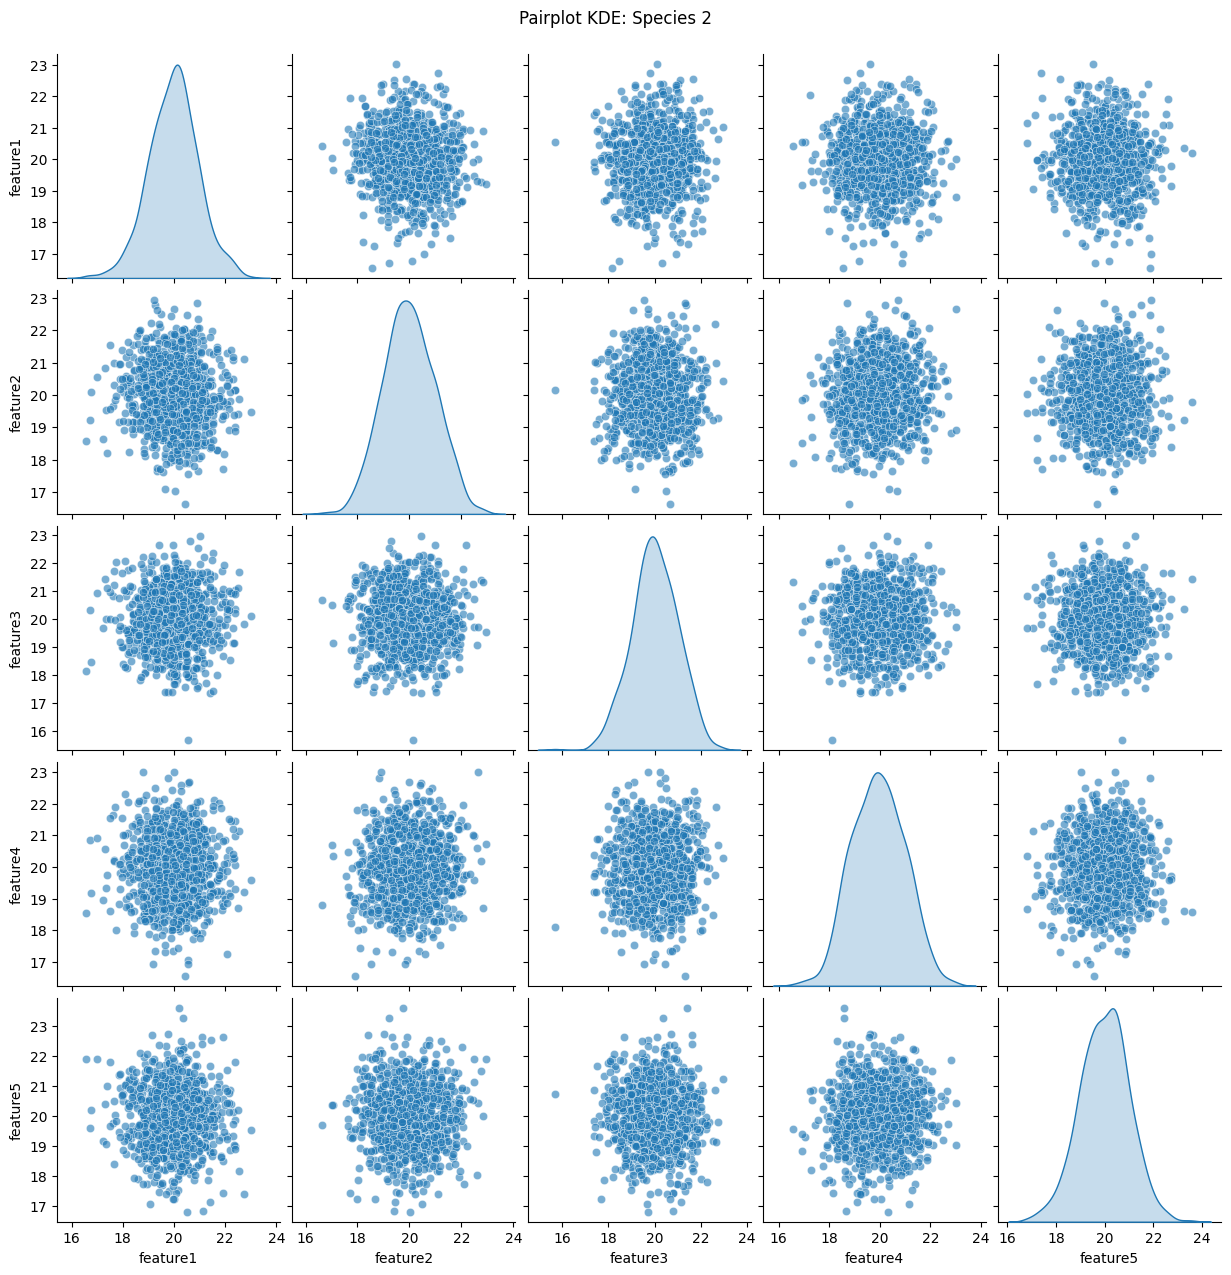

In [36]:
# === Pairplot с KDE на диагонали для выбранных признаков ===
selected_features = feature_names[:5]  # можно выбрать меньше признаков для наглядности

sns.pairplot(
    data=df1,
    vars=selected_features,
    hue='species',
    plot_kws={'alpha': 0.6},
    diag_kind='kde',   # KDE на диагонали
)
plt.show()

# === Pairplot по классам (по желанию) ===
for cls in df1['species'].unique():
    sns.pairplot(
        data=df1[df1['species'] == cls],
        vars=selected_features,
        plot_kws={'alpha': 0.6},
        diag_kind='kde'
    )
    plt.suptitle(f"Pairplot KDE: Species {cls}", y=1.02)
    plt.show()

# [2] Oversample df...

In [37]:
def oversample_class(df, target_class, repeat_list, class_col='species'):
    if target_class not in df[class_col].unique():
        raise ValueError(f"Class {target_class} not found in column '{class_col}'")

    df_target = df[df[class_col] == target_class]
    df_rest = df[df[class_col] != target_class]

    oversampled = {}

    for r in repeat_list:
        df_new = pd.concat([df_target] * r + [df_rest], ignore_index=True)
        oversampled[f'df{r}'] = df_new.copy()
    
    return oversampled

repeat_list = [2, 5, 10, 20, 50, 100, 1000, 10000]
target_class = 0
oversampled_datasets = oversample_class(df1, target_class, repeat_list)

for name, df in oversampled_datasets.items():
    print(name, df.shape)

df2 (4000, 17)
df5 (7000, 17)
df10 (12000, 17)
df20 (22000, 17)
df50 (52000, 17)
df100 (102000, 17)
df1000 (1002000, 17)
df10000 (10002000, 17)


# [3] - [6]: LDA + PR + ROC ++++

In [38]:
def bootstrap_curve(y_true, scores, n_boot=1000, grid_len=200, curve_type='roc', random_state=42, n_jobs=-1):

    rng = np.random.default_rng(random_state)
    n_samples = len(y_true)
    grid = np.linspace(0, 1, grid_len)
    tprs_boot = np.zeros((n_boot, grid_len))
    aucs_boot = np.zeros(n_boot)

    def one_boot(_):
        idx = rng.integers(0, n_samples, n_samples)
        y_b, s_b = y_true[idx], scores[idx]
        if len(np.unique(y_b)) < 2:
            return np.zeros(grid_len), np.nan

        if curve_type == 'roc':
            fpr, tpr, _ = roc_curve(y_b, s_b)
            auc_val = auc(fpr, tpr)
            tpr_interp = np.interp(grid, fpr, tpr)
        elif curve_type == 'pr':
            precision, recall, _ = precision_recall_curve(y_b, s_b)
            auc_val = average_precision_score(y_b, s_b)
            # Обратная интерполяция recall->precision для возрастающей сетки
            tpr_interp = np.interp(grid, recall[::-1], precision[::-1])
        else:
            raise ValueError("curve_type должен быть 'roc' или 'pr'")
        return tpr_interp, auc_val
    
    # Параллельный бутстрэп с tqdm
    results = Parallel(n_jobs=n_jobs)(
        delayed(one_boot)(i) for i in tqdm(range(n_boot), desc="Bootstrap progress")
    )

    for i, (tpr_interp, auc_val) in enumerate(results):
        tprs_boot[i, :] = tpr_interp
        aucs_boot[i] = auc_val

    valid_aucs = aucs_boot[~np.isnan(aucs_boot)]
    if valid_aucs.size == 0:
        auc_ci = (np.nan, np.nan)
        tpr_lower = np.zeros_like(grid)
        tpr_upper = np.zeros_like(grid)
    else:
        auc_ci = (np.percentile(valid_aucs, 2.5), np.percentile(valid_aucs, 97.5))
        tprs_valid = tprs_boot[~np.isnan(aucs_boot), :]
        tpr_lower = np.percentile(tprs_valid, 2.5, axis=0)
        tpr_upper = np.percentile(tprs_valid, 97.5, axis=0)

    return {
        'grid': grid,
        'tprs_boot': tprs_boot,
        'tpr_lower': tpr_lower,
        'tpr_upper': tpr_upper,
        'auc_ci': auc_ci,
        'aucs_boot': aucs_boot
    }

In [39]:

def analyze_lda(df, class_pair=(0,1), features=('feature1','feature2'), target_class=None,
                n_boot=1000, grid_len=200, random_state=42, figsize=(14,6),
                show=True, n_jobs=-1):
    
    np.random.seed(random_state)
    if target_class is None:
        target_class = class_pair[0]
    
    # Отбор нужных классов
    df2 = df[df['species'].isin(class_pair)].copy()
    if df2.empty:
        raise ValueError("После фильтрации DataFrame пуст. Проверьте class_pair.")

    X = df2[list(features)].values
    y = df2['species'].values
    y_bin = (y == target_class).astype(int)

    # === LDA fit ===
    lda = LinearDiscriminantAnalysis()
    t0 = time.time()
    lda.fit(X, y_bin)
    lda_time = time.time() - t0

    # === Решающее поле ===
    x_min, x_max = X[:,0].min() - 1.0, X[:,0].max() + 1.0
    y_min, y_max = X[:,1].min() - 1.0, X[:,1].max() + 1.0
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    try:
        Z = lda.decision_function(grid_points)
    except:
        Z = lda.predict_proba(grid_points)[:,1]
    Z = Z.reshape(xx.shape)

    # === Центры классов ===
    centers = {}
    for cls in class_pair:
        Xc = df2[df2['species']==cls][list(features)].values
        centers[f'class_{cls}'] = Xc.mean(axis=0)
    centers['global_center'] = np.vstack([centers[f'class_{c}'] for c in class_pair]).mean(axis=0)
    centers['segment_mid'] = (centers[f'class_{class_pair[0]}'] + centers[f'class_{class_pair[1]}']) / 2.0

    # === Scores для ROC/PR ===
    try:
        scores = lda.decision_function(X)
    except:
        scores = lda.predict_proba(X)[:,1]

    # === ROC/PR бутстрэп ===
    roc_result = bootstrap_curve(y_bin, scores, n_boot=n_boot, grid_len=grid_len,
                                 curve_type='roc', random_state=random_state, n_jobs=n_jobs)
    pr_result = bootstrap_curve(y_bin, scores, n_boot=n_boot, grid_len=grid_len,
                                curve_type='pr', random_state=random_state, n_jobs=n_jobs)
    
    # === Визуализация ===
    fig, axes = plt.subplots(1,2, figsize=figsize)
    ax0, ax1 = axes

    # Левая: LDA пространство
    ax0.contourf(xx, yy, Z>0, levels=[-1,0,1], colors=["#f86969","#8bff8b"], alpha=0.3)
    ax0.contour(xx, yy, Z, levels=[0], linewidths=2, linestyles='--', colors='black')
    for cls in class_pair:
        sel = df2['species']==cls
        color = 'green' if cls==target_class else 'red'
        ax0.scatter(df2.loc[sel, features[0]], df2.loc[sel, features[1]], s=30, alpha=0.7,
                    label=f'class {cls}', color=color)
        
    # Центры и линия
    c0, c1 = centers[f'class_{class_pair[0]}'], centers[f'class_{class_pair[1]}']
    ax0.scatter([c0[0]], [c0[1]], s=120, marker='X', edgecolor='k', linewidth=1.2)
    ax0.scatter([c1[0]], [c1[1]], s=120, marker='X', edgecolor='k', linewidth=1.2)
    ax0.plot([c0[0], c1[0]], [c0[1], c1[1]], linestyle='-', linewidth=2, alpha=0.7)
    mid = (c0+c1)/2
    ax0.scatter([mid[0]], [mid[1]], s=80, marker='o', facecolors='none', edgecolor='k')

    ax0.set_xlabel(features[0])
    ax0.set_ylabel(features[1])
    ax0.set_title('LDA decision regions + data')
    ax0.legend()
    ax0.grid(True, alpha=0.2)
    ax0.text(0.01, 0.99, f'LDA fit time: {lda_time:.4f} s', transform=ax0.transAxes,
             verticalalignment='top', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
    
    # Правая: ROC и PR кривые
    ax1.plot(roc_result['grid'], roc_result['tprs_boot'].mean(axis=0), lw=2,
             label=f'ROC mean AUC = {roc_result["aucs_boot"].mean():.3f}')
    ax1.fill_between(roc_result['grid'], roc_result['tpr_lower'], roc_result['tpr_upper'], alpha=0.25,
                     label='ROC 95% CI')
    ax1.plot(pr_result['grid'], pr_result['tprs_boot'].mean(axis=0), lw=2, color='orange',
             label=f'PR mean AUPRC = {pr_result["aucs_boot"].mean():.3f}')
    ax1.fill_between(pr_result['grid'], pr_result['tpr_lower'], pr_result['tpr_upper'], alpha=0.15,
                     color='orange', label='PR 95% CI')
    ax1.plot([0,1],[0,1], linestyle='--', color='grey', linewidth=1)
    ax1.set_xlabel('FPR / Recall')
    ax1.set_ylabel('TPR / Precision')
    ax1.set_title(f'ROC & PR curves (target class={target_class})')
    ax1.legend(loc='lower right')
    ax1.grid(True, alpha=0.2)

    if show:
        plt.tight_layout()
        plt.show()

    return {
        'fig': fig,
        'lda_time': lda_time,
        'centers': centers,
        'roc_result': roc_result,
        'pr_result': pr_result,
        'scores': scores,
        'y_bin': y_bin
    }


=== Анализ для df2 ===


Bootstrap progress: 100%|██████████| 1500/1500 [00:00<00:00, 10495.89it/s]


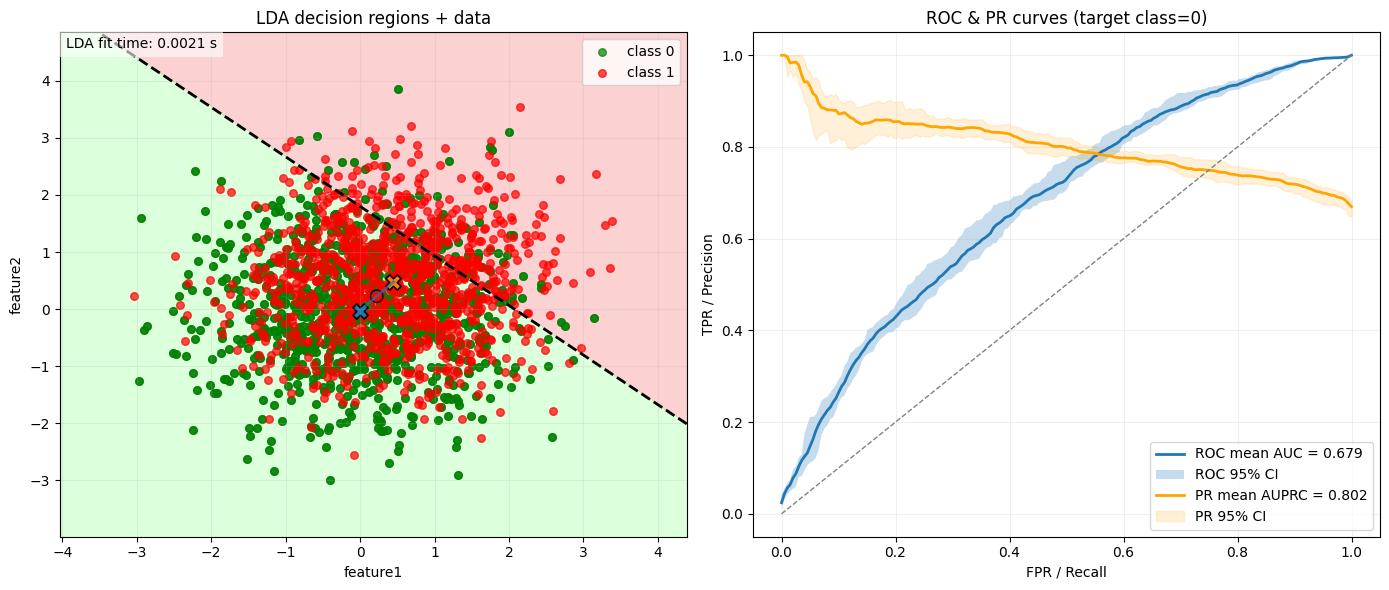

ROC AUC = 0.679, CI95 = [0.669, 0.695]
PR AUPRC = 0.802, CI95 = [0.790, 0.818]

=== Анализ для df5 ===


Bootstrap progress: 100%|██████████| 1500/1500 [00:00<00:00, 8581.47it/s]


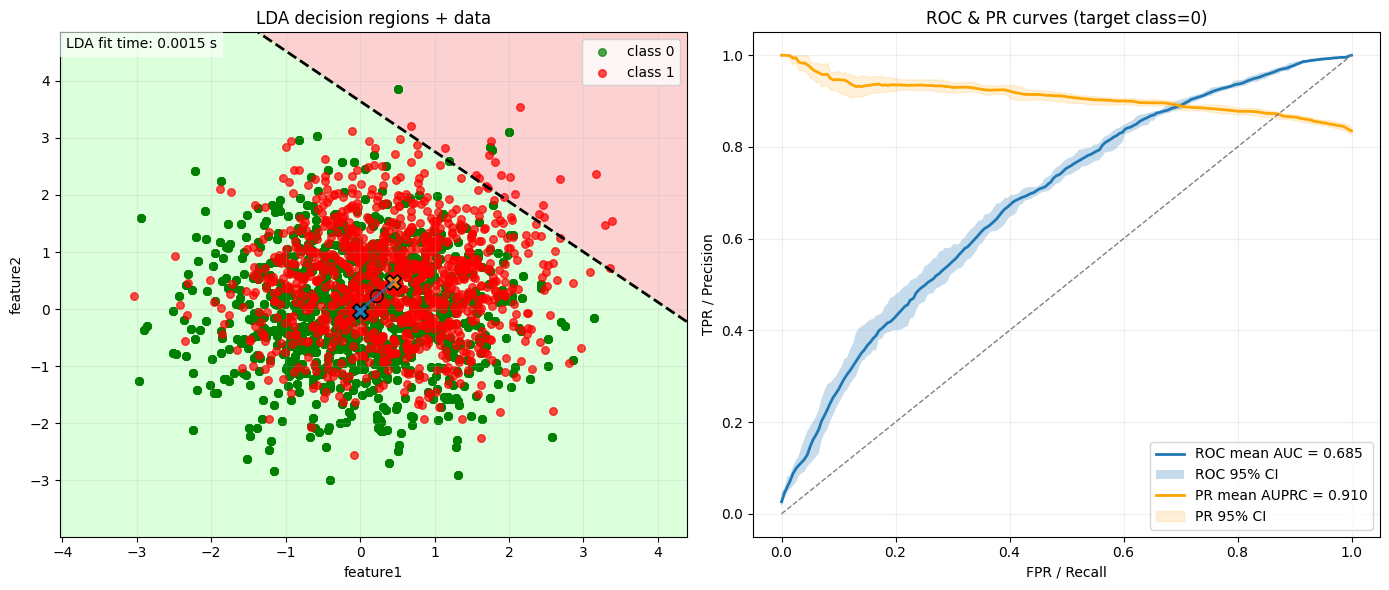

ROC AUC = 0.685, CI95 = [0.672, 0.701]
PR AUPRC = 0.910, CI95 = [0.902, 0.918]

=== Анализ для df10 ===


Bootstrap progress: 100%|██████████| 1500/1500 [00:00<00:00, 6820.51it/s]


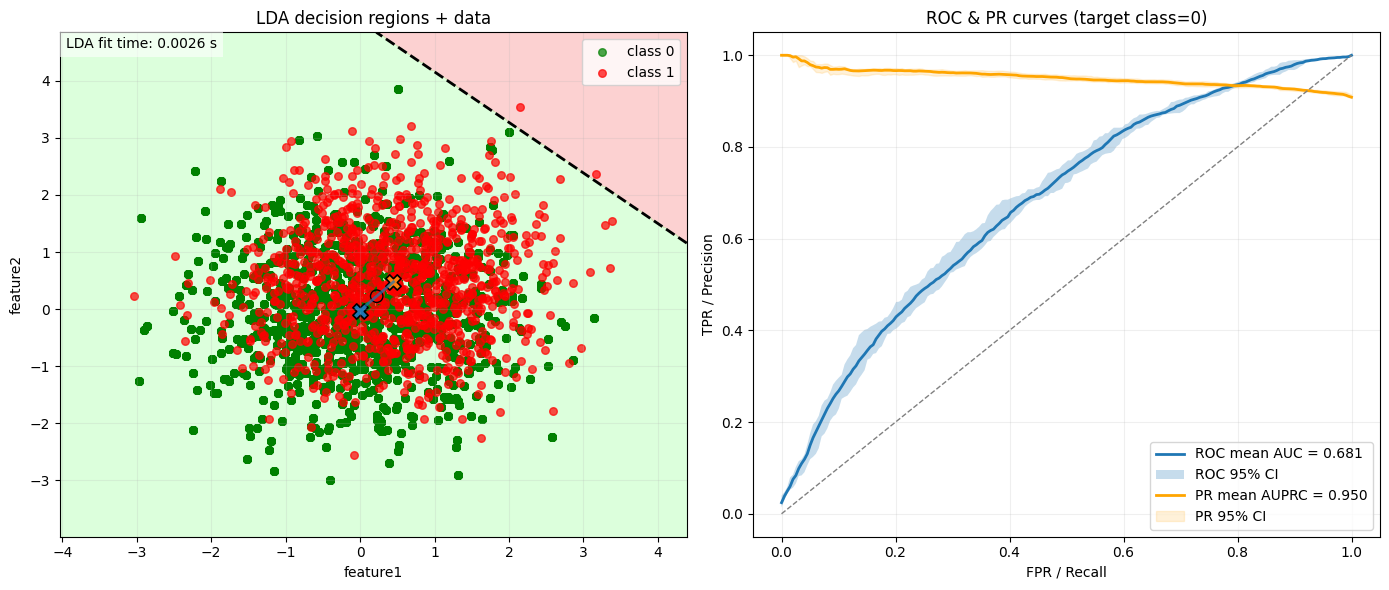

ROC AUC = 0.681, CI95 = [0.667, 0.700]
PR AUPRC = 0.950, CI95 = [0.946, 0.954]

=== Анализ для df20 ===


Bootstrap progress: 100%|██████████| 1500/1500 [00:00<00:00, 4880.52it/s]


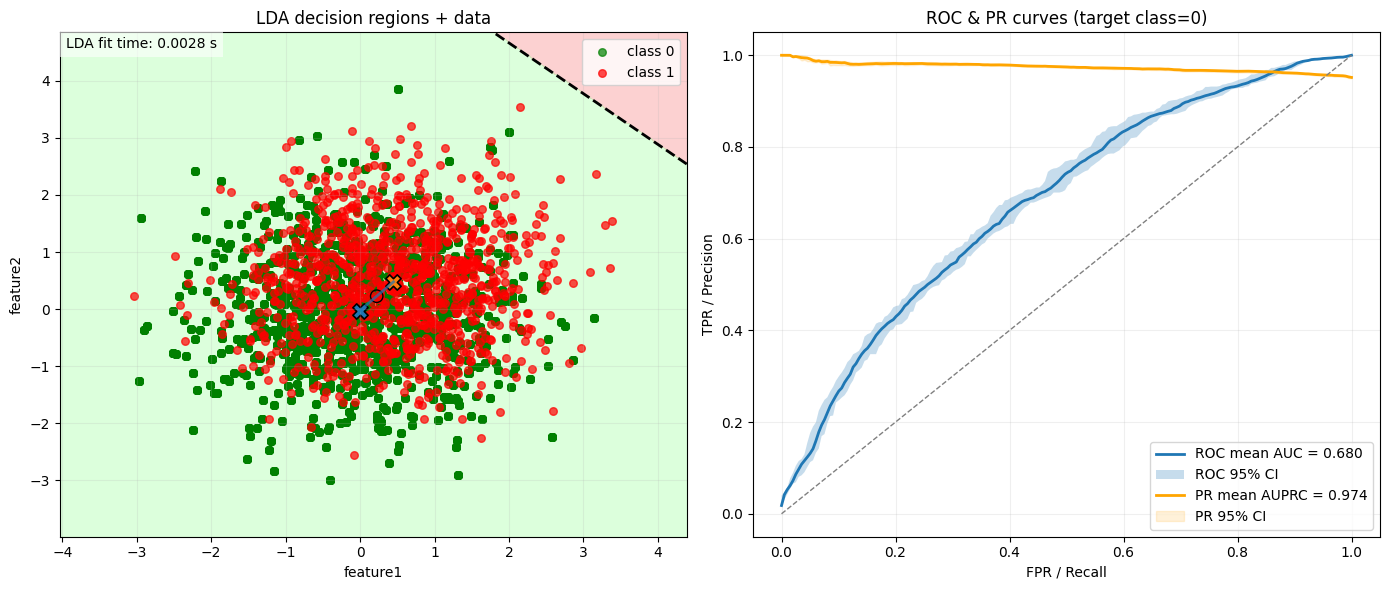

ROC AUC = 0.680, CI95 = [0.669, 0.699]
PR AUPRC = 0.974, CI95 = [0.973, 0.977]

=== Анализ для df50 ===


Bootstrap progress: 100%|██████████| 1500/1500 [00:00<00:00, 1819.53it/s]


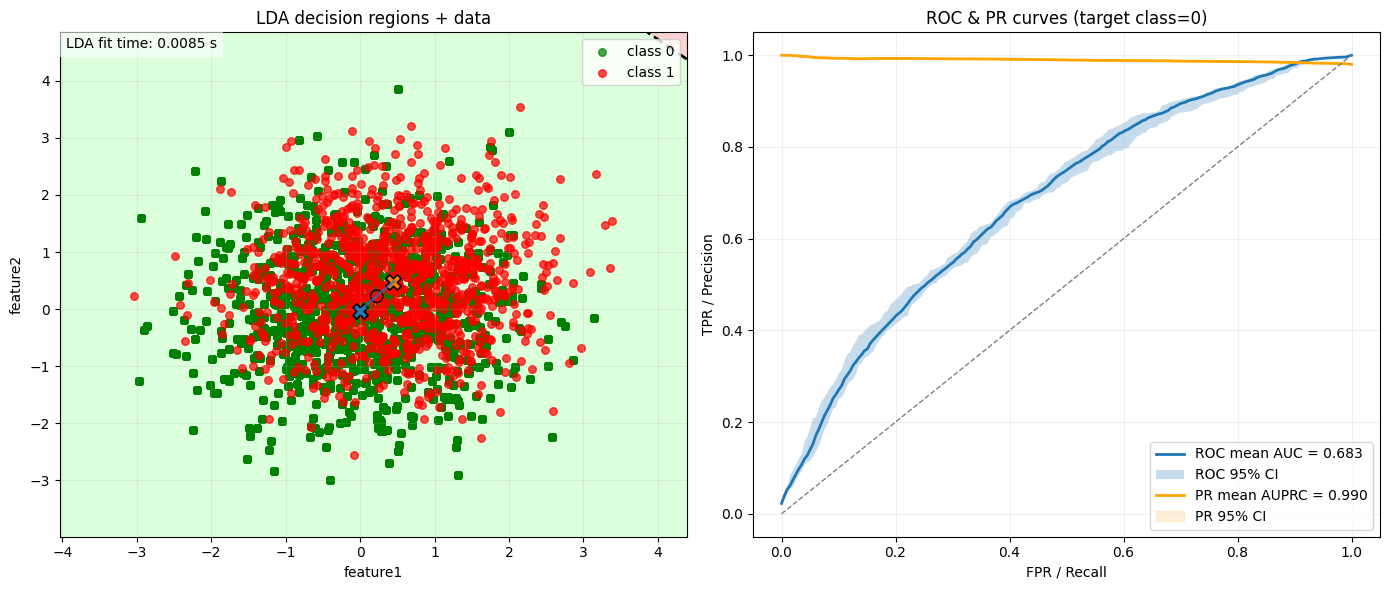

ROC AUC = 0.683, CI95 = [0.668, 0.693]
PR AUPRC = 0.990, CI95 = [0.989, 0.991]

=== Анализ для df100 ===


Bootstrap progress: 100%|██████████| 1500/1500 [00:02<00:00, 681.10it/s]


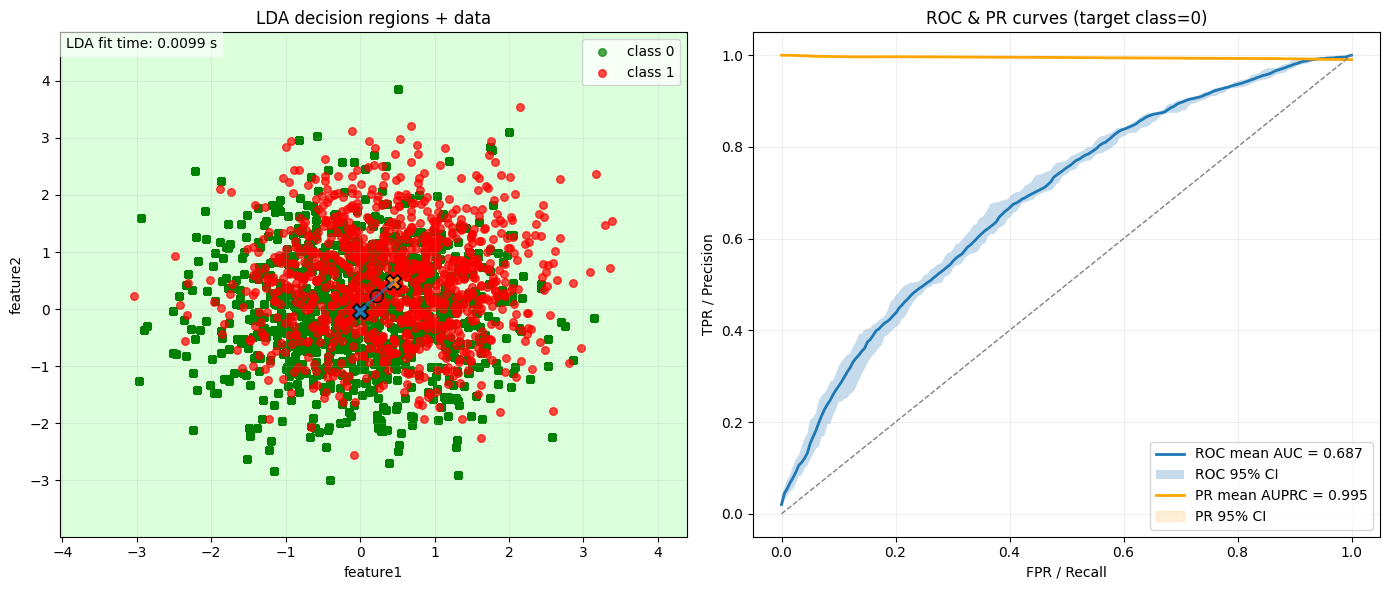

ROC AUC = 0.687, CI95 = [0.675, 0.699]
PR AUPRC = 0.995, CI95 = [0.995, 0.995]

=== Анализ для df1000 ===


Bootstrap progress: 100%|██████████| 1500/1500 [00:35<00:00, 42.18it/s]


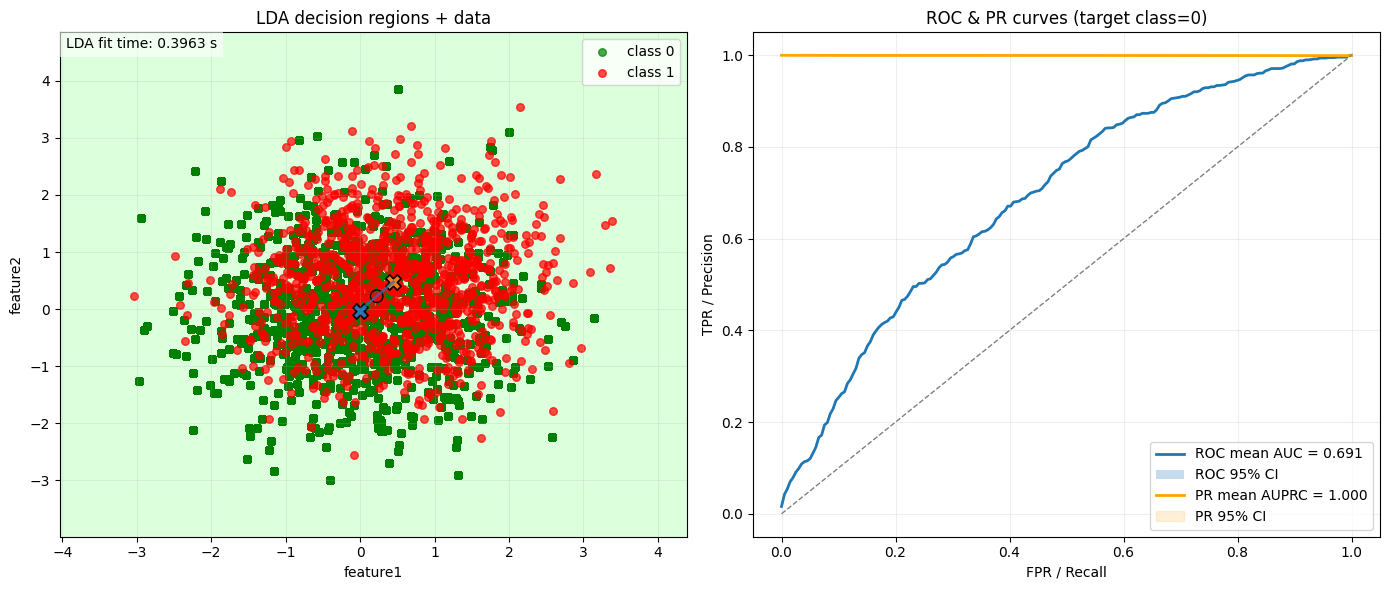

ROC AUC = 0.691, CI95 = [0.691, 0.691]
PR AUPRC = 1.000, CI95 = [1.000, 1.000]

=== Анализ для df10000 ===


Bootstrap progress: 100%|██████████| 1500/1500 [10:09<00:00,  2.46it/s]
/tmp/ipykernel_9514/3509208738.py:101: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/toasty/repos/tsd/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


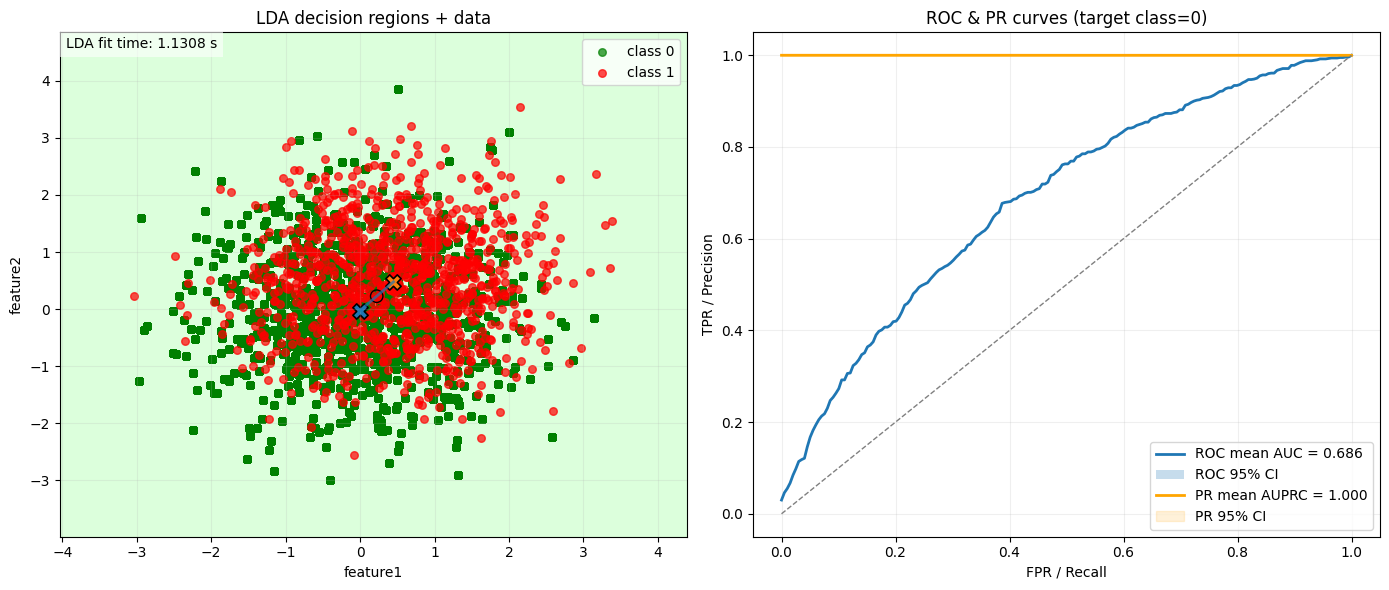

ROC AUC = 0.686, CI95 = [0.686, 0.686]
PR AUPRC = 1.000, CI95 = [1.000, 1.000]

=== Анализ для df1 ===


Bootstrap progress: 100%|██████████| 1500/1500 [00:00<00:00, 11111.09it/s]


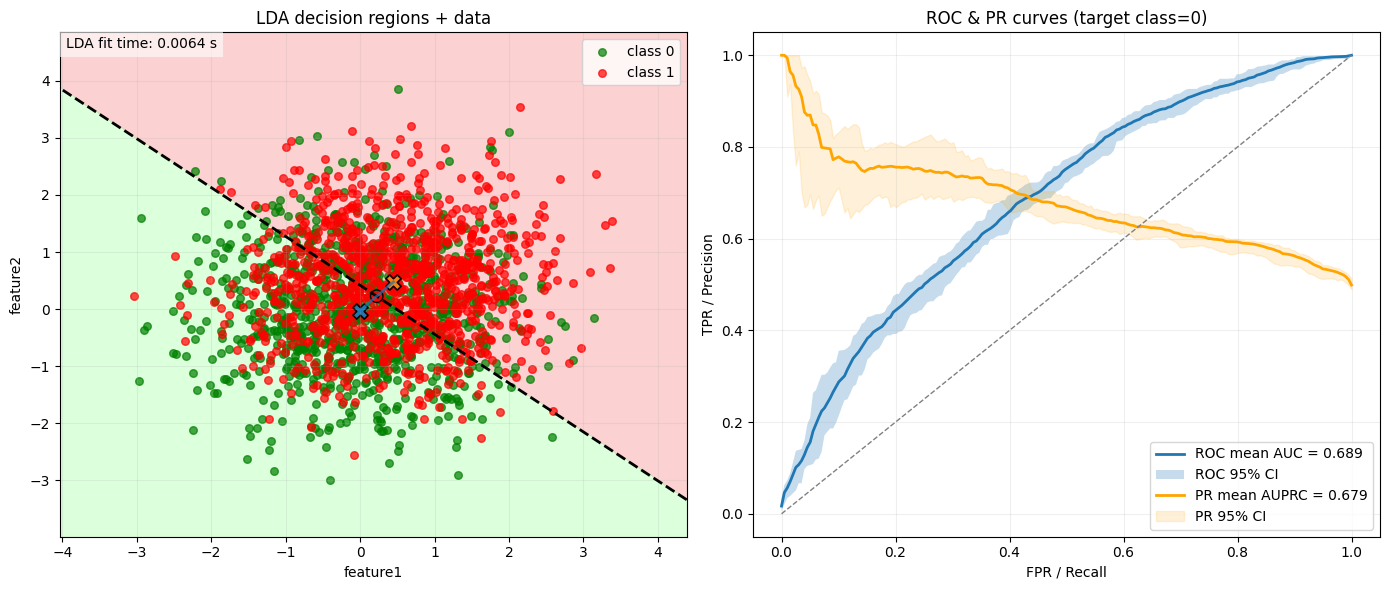

ROC AUC = 0.689, CI95 = [0.671, 0.707]
PR AUPRC = 0.679, CI95 = [0.646, 0.703]


,dataset,roc_auc_mean,roc_ci_lower,roc_ci_upper,pr_auc_mean,pr_ci_lower,pr_ci_upper,lda_time_s,c0_x,c0_y,c1_x,c1_y,global_center_x,global_center_y,segment_mid_x,segment_mid_y
0,df2,0.678952,0.669184,0.695304,0.802398,0.790022,0.817926,0.002138,-0.00231,-0.027733,0.448389,0.477096,0.22304,0.224682,0.22304,0.224682
1,df5,0.685203,0.672023,0.701000,0.909616,0.901509,0.918038,0.001457,-0.00231,-0.027733,0.448389,0.477096,0.22304,0.224682,0.22304,0.224682
2,df10,0.680586,0.666860,0.699739,0.950399,0.945734,0.954370,0.002566,-0.00231,-0.027733,0.448389,0.477096,0.22304,0.224682,0.22304,0.224682
3,df20,0.680430,0.668511,0.698565,0.974143,0.972503,0.976638,0.002800,-0.00231,-0.027733,0.448389,0.477096,0.22304,0.224682,0.22304,0.224682
4,df50,0.683279,0.668278,0.693457,0.989638,0.988950,0.990525,0.008459,-0.00231,-0.027733,0.448389,0.477096,0.22304,0.224682,0.22304,0.224682
5,df100,0.686694,0.674702,0.699017,0.994977,0.994819,0.995379,0.009924,-0.00231,-0.027733,0.448389,0.477096,0.22304,0.224682,0.22304,0.224682
6,df1000,0.690767,0.690767,0.690767,0.999519,0.999519,0.999519,0.396334,-0.00231,-0.027733,0.448389,0.477096,0.22304,0.224682,0.22304,0.224682
7,df10000,0.685897,0.685897,0.685897,0.999948,0.999948,0.999948,1.130754,-0.00231,-0.027733,0.448389,0.477096,0.22304,0.224682,0.22304,0.224682
8,df1,0.689225,0.670765,0.706512,0.678897,0.646486,0.702786,0.006412,-0.00231,-0.027733,0.448389,0.477096,0.22304,0.224682,0.22304,0.224682


In [40]:
results_table = []

oversampled_datasets['df1'] = df1

for name, dfN in oversampled_datasets.items():
    print(f"\n=== Анализ для {name} ===")
    result = analyze_lda(
        df=dfN,
        class_pair=(0,1),
        features=('feature1','feature2'),
        target_class=0,
        n_boot=1500,
        show=True,
        n_jobs=-1
    )

    roc_auc_mean = np.mean(result['roc_result']['aucs_boot'])
    roc_ci = result['roc_result']['auc_ci']
    pr_auc_mean = np.mean(result['pr_result']['aucs_boot'])
    pr_ci = result['pr_result']['auc_ci']
    
    print(f"ROC AUC = {roc_auc_mean:.3f}, CI95 = [{roc_ci[0]:.3f}, {roc_ci[1]:.3f}]")
    print(f"PR AUPRC = {pr_auc_mean:.3f}, CI95 = [{pr_ci[0]:.3f}, {pr_ci[1]:.3f}]")

    # Добавляем в таблицу
    results_table.append({
        'dataset': name,
        'roc_auc_mean': roc_auc_mean,
        'roc_ci_lower': roc_ci[0],
        'roc_ci_upper': roc_ci[1],
        'pr_auc_mean': pr_auc_mean,
        'pr_ci_lower': pr_ci[0],
        'pr_ci_upper': pr_ci[1],
        'lda_time_s': result['lda_time'],
        'c0_x': result['centers']['class_0'][0],
        'c0_y': result['centers']['class_0'][1],
        'c1_x': result['centers']['class_1'][0],
        'c1_y': result['centers']['class_1'][1],
        'global_center_x': result['centers']['global_center'][0],
        'global_center_y': result['centers']['global_center'][1],
        'segment_mid_x': result['centers']['segment_mid'][0],
        'segment_mid_y': result['centers']['segment_mid'][1]
    })

# Преобразуем в DataFrame для удобного анализа
results_df_0 = pd.DataFrame(results_table)
results_df_0

# [7]: Target Switch


=== Анализ для df2 ===


Bootstrap progress: 100%|██████████| 1500/1500 [00:00<00:00, 10228.71it/s]


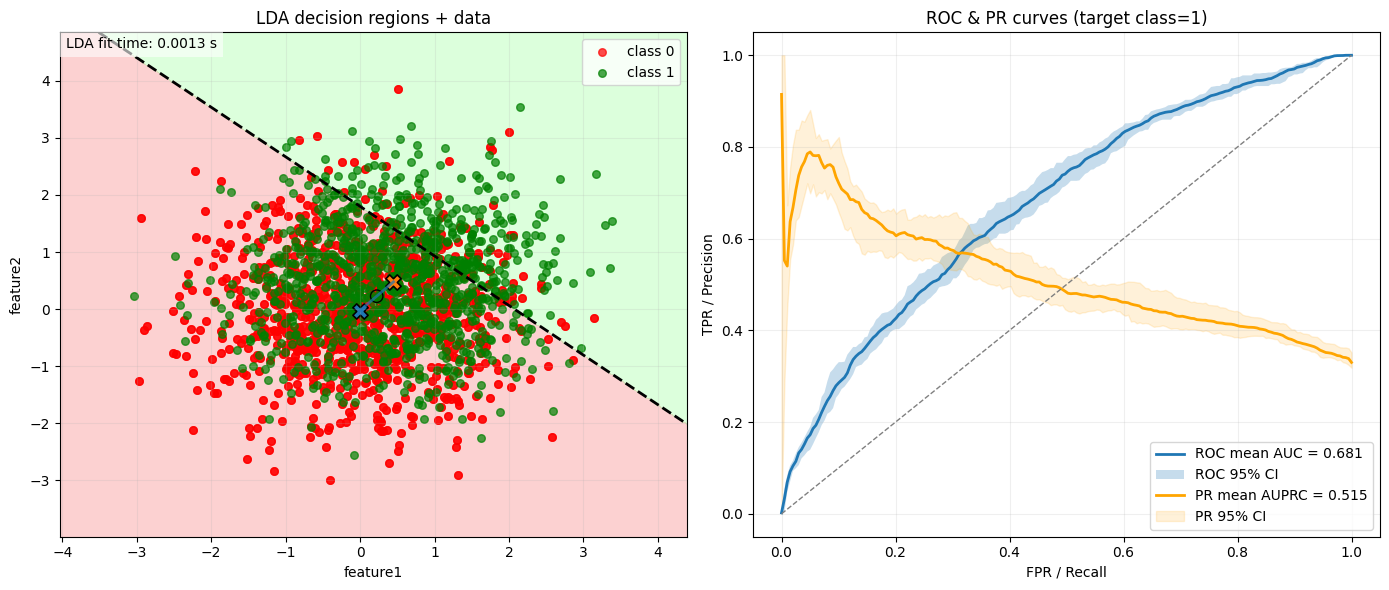

ROC AUC = 0.681, CI95 = [0.669, 0.695]
PR AUPRC = 0.515, CI95 = [0.482, 0.553]

=== Анализ для df5 ===


Bootstrap progress: 100%|██████████| 1500/1500 [00:00<00:00, 9270.91it/s]


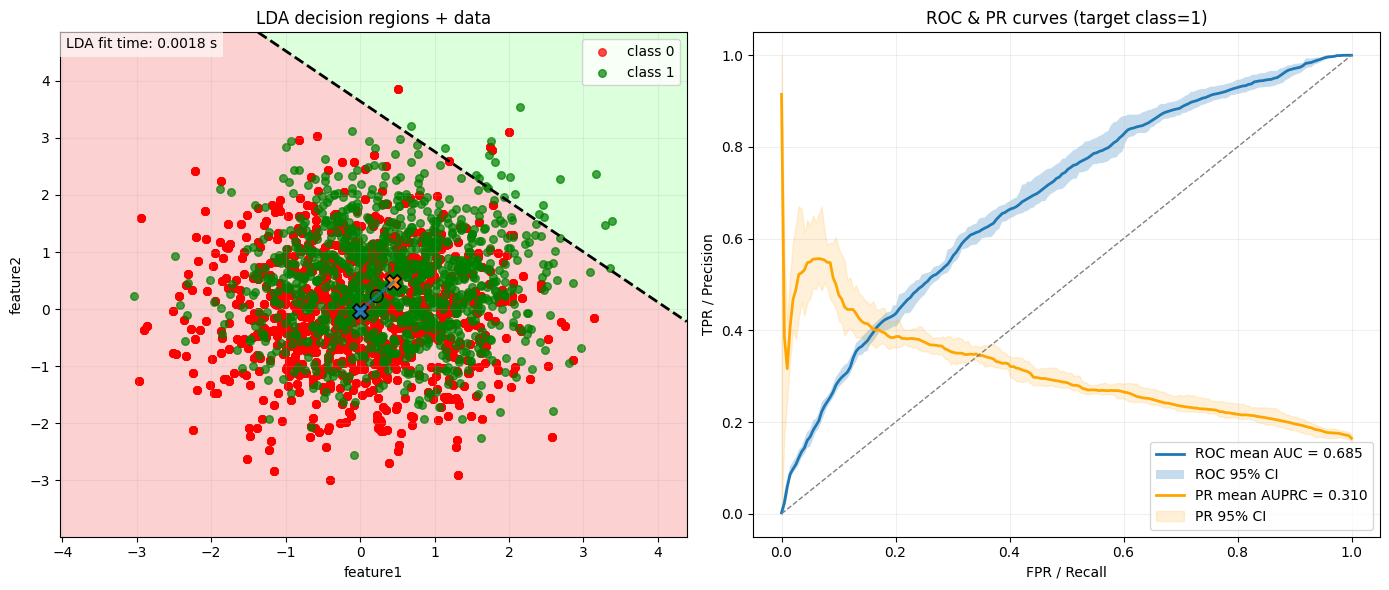

ROC AUC = 0.685, CI95 = [0.672, 0.701]
PR AUPRC = 0.310, CI95 = [0.297, 0.326]

=== Анализ для df10 ===


Bootstrap progress: 100%|██████████| 1500/1500 [00:00<00:00, 7231.87it/s]


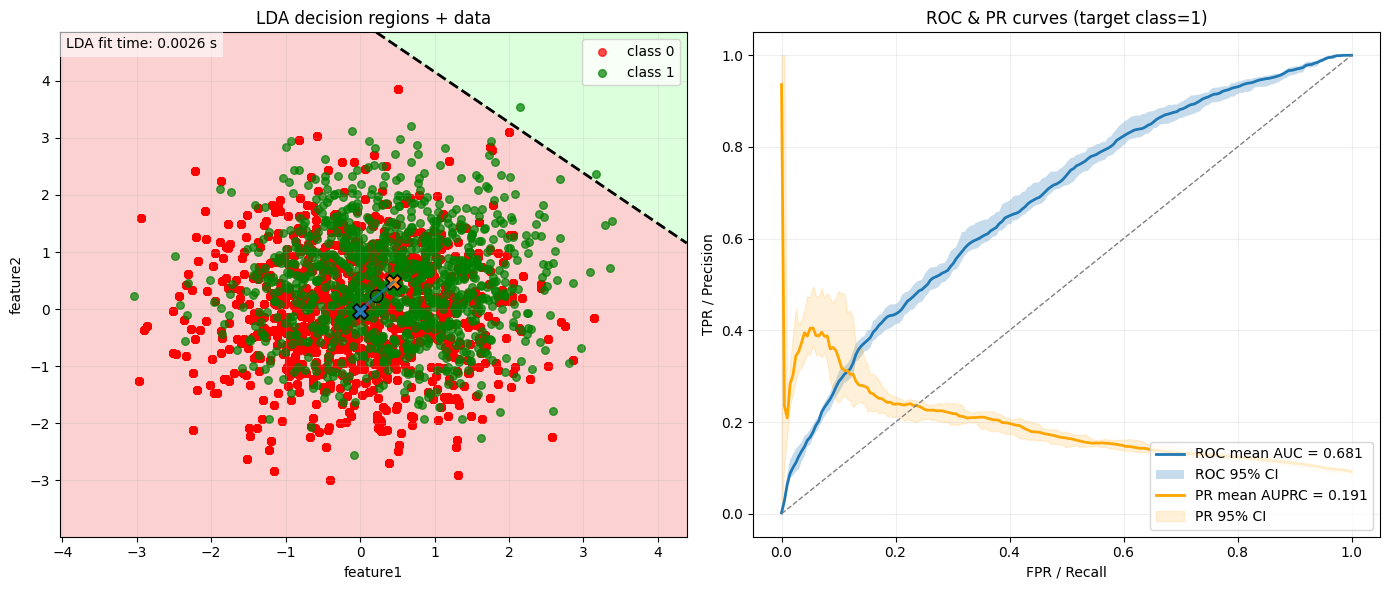

ROC AUC = 0.681, CI95 = [0.667, 0.700]
PR AUPRC = 0.191, CI95 = [0.181, 0.211]

=== Анализ для df20 ===


Bootstrap progress: 100%|██████████| 1500/1500 [00:00<00:00, 5173.74it/s]


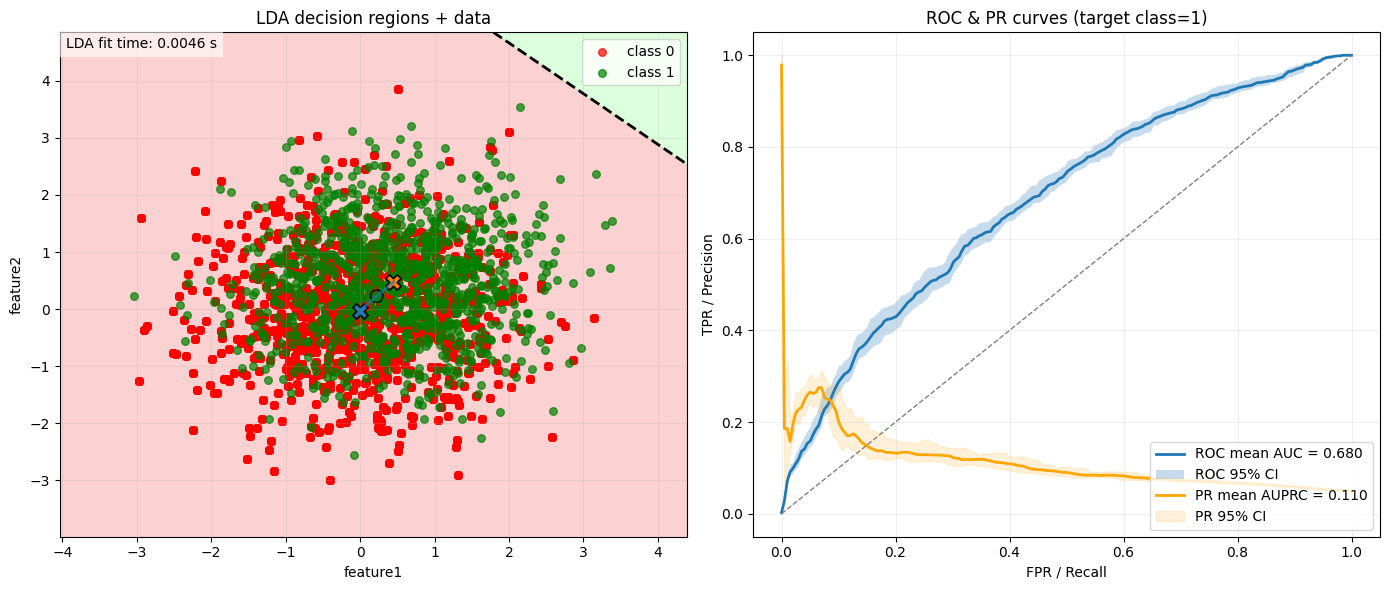

ROC AUC = 0.680, CI95 = [0.669, 0.699]
PR AUPRC = 0.110, CI95 = [0.099, 0.126]

=== Анализ для df50 ===


Bootstrap progress: 100%|██████████| 1500/1500 [00:00<00:00, 1747.87it/s]


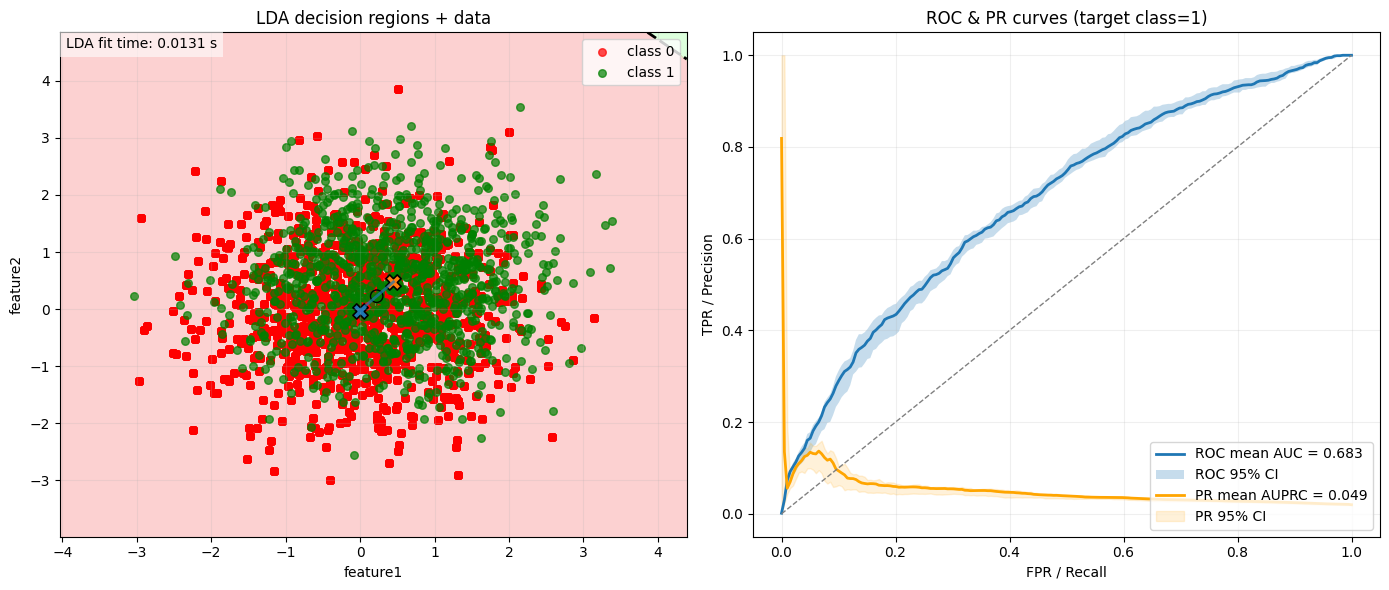

ROC AUC = 0.683, CI95 = [0.668, 0.693]
PR AUPRC = 0.049, CI95 = [0.038, 0.054]

=== Анализ для df100 ===


Bootstrap progress: 100%|██████████| 1500/1500 [00:02<00:00, 653.56it/s]


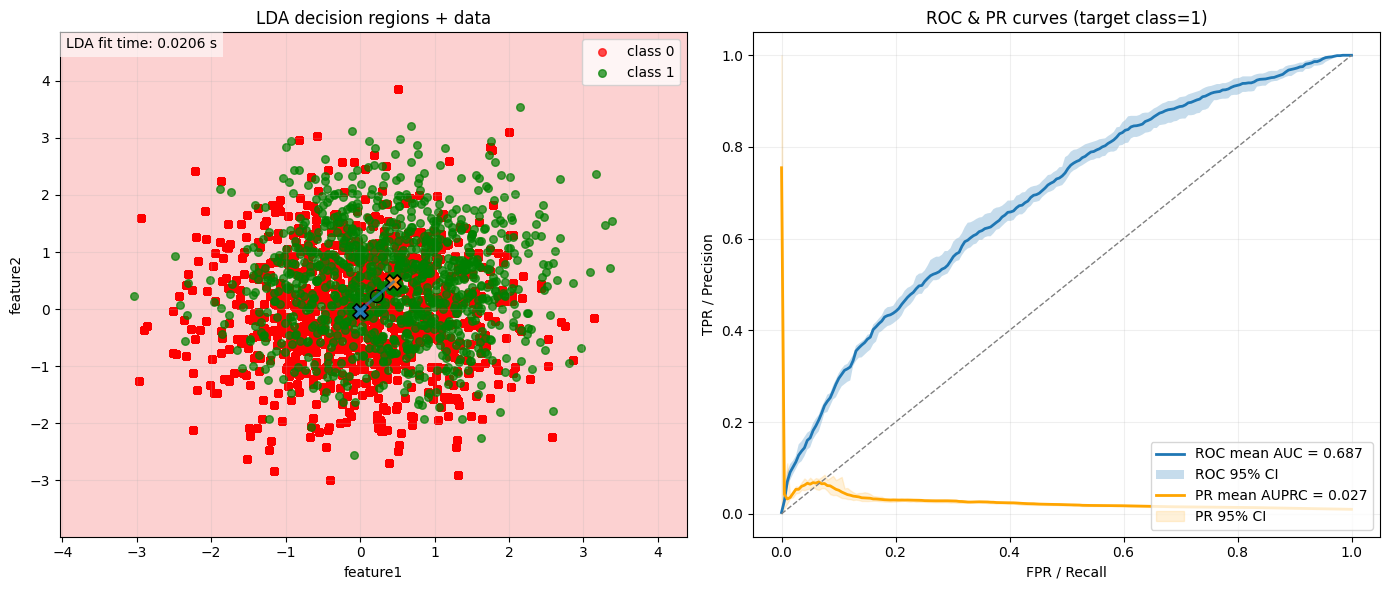

ROC AUC = 0.687, CI95 = [0.675, 0.699]
PR AUPRC = 0.027, CI95 = [0.023, 0.031]

=== Анализ для df1000 ===


Bootstrap progress: 100%|██████████| 1500/1500 [00:33<00:00, 45.42it/s]


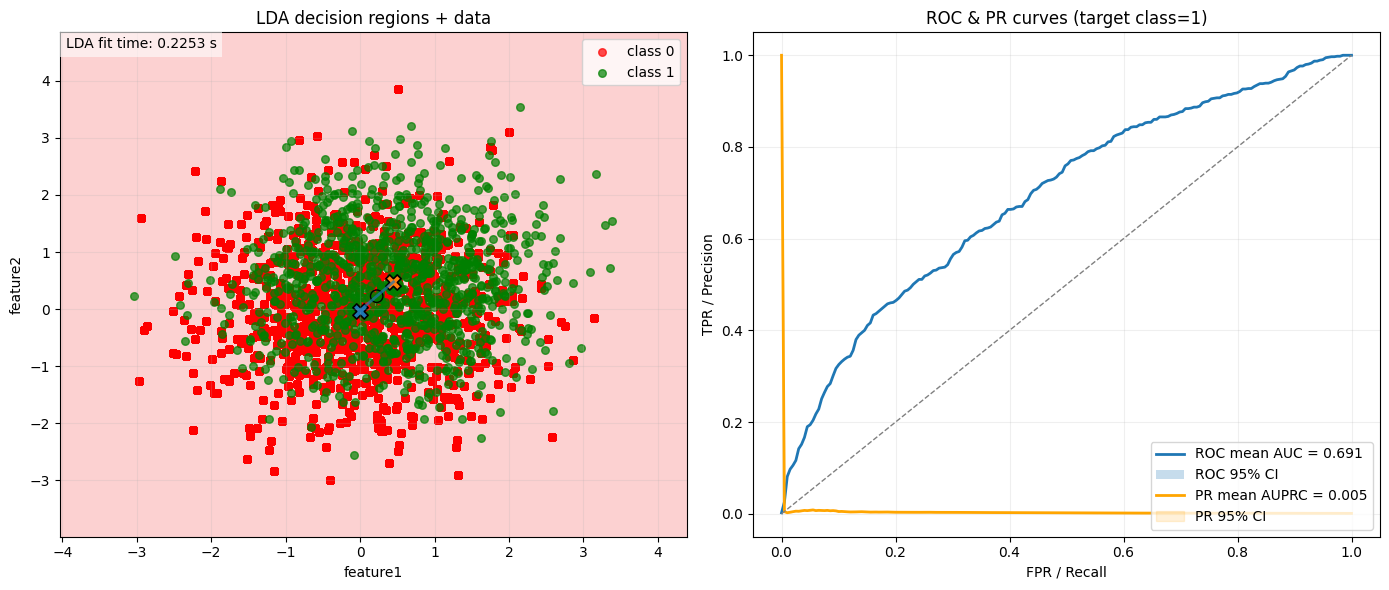

ROC AUC = 0.691, CI95 = [0.691, 0.691]
PR AUPRC = 0.005, CI95 = [0.005, 0.005]

=== Анализ для df10000 ===


Bootstrap progress: 100%|██████████| 1500/1500 [09:57<00:00,  2.51it/s]
/tmp/ipykernel_9514/3509208738.py:101: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/toasty/repos/tsd/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


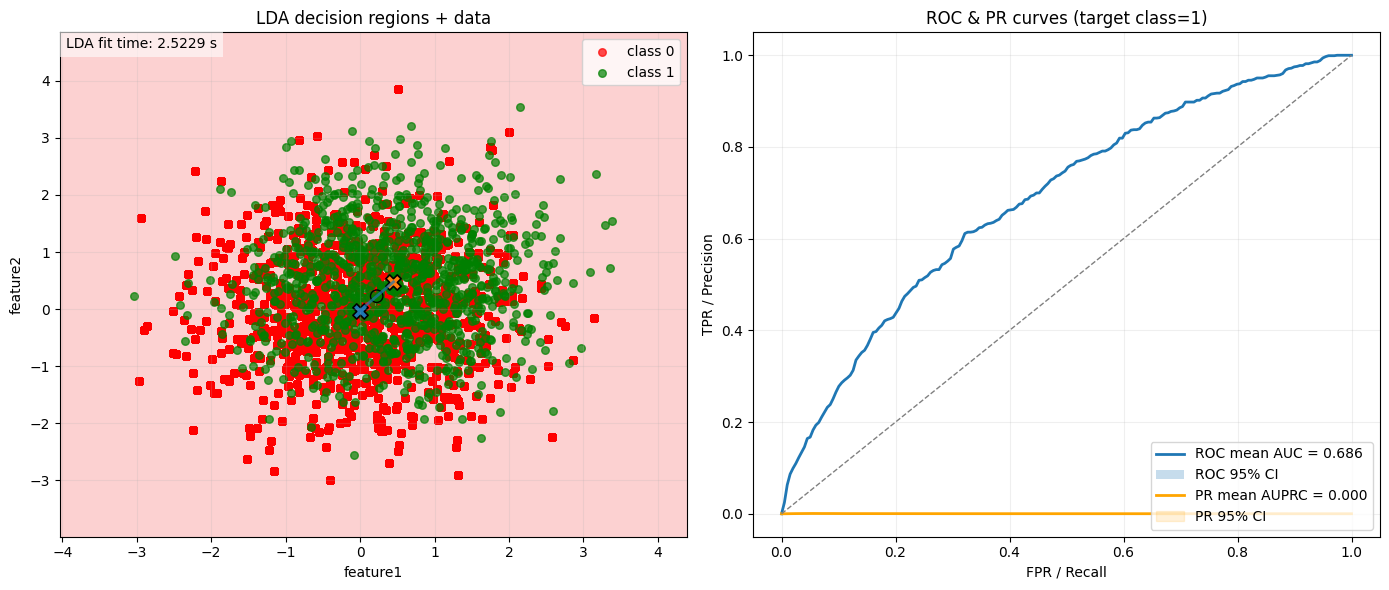

ROC AUC = 0.686, CI95 = [0.686, 0.686]
PR AUPRC = 0.000, CI95 = [0.000, 0.000]

=== Анализ для df1 ===


Bootstrap progress: 100%|██████████| 1500/1500 [00:00<00:00, 10814.56it/s]


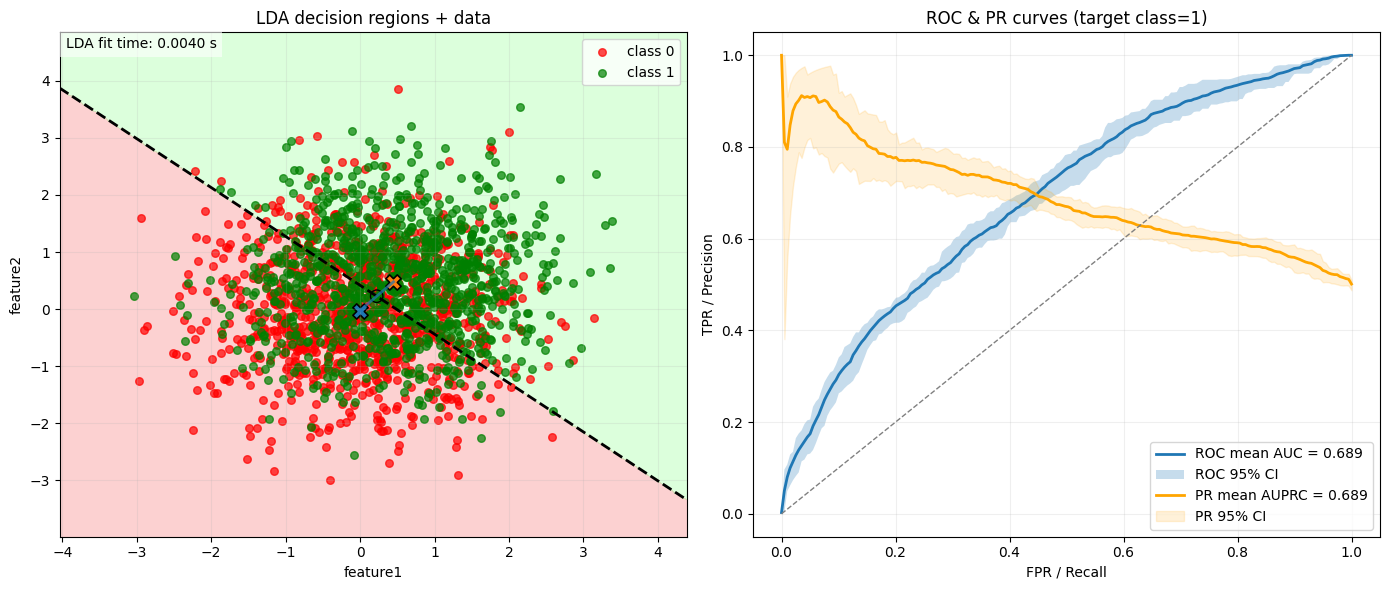

ROC AUC = 0.689, CI95 = [0.671, 0.707]
PR AUPRC = 0.689, CI95 = [0.656, 0.718]


,dataset,roc_auc_mean,roc_ci_lower,roc_ci_upper,pr_auc_mean,pr_ci_lower,pr_ci_upper,lda_time_s,c0_x,c0_y,c1_x,c1_y,global_center_x,global_center_y,segment_mid_x,segment_mid_y
0,df2,0.681212,0.669184,0.695304,0.515335,0.482003,0.553485,0.001274,-0.00231,-0.027733,0.448389,0.477096,0.22304,0.224682,0.22304,0.224682
1,df5,0.685203,0.672023,0.701000,0.310143,0.297136,0.325840,0.001829,-0.00231,-0.027733,0.448389,0.477096,0.22304,0.224682,0.22304,0.224682
2,df10,0.680586,0.666860,0.699739,0.191191,0.180836,0.211105,0.002582,-0.00231,-0.027733,0.448389,0.477096,0.22304,0.224682,0.22304,0.224682
3,df20,0.680430,0.668511,0.698565,0.110256,0.099094,0.125748,0.004581,-0.00231,-0.027733,0.448389,0.477096,0.22304,0.224682,0.22304,0.224682
4,df50,0.683279,0.668278,0.693457,0.049305,0.038298,0.054383,0.013104,-0.00231,-0.027733,0.448389,0.477096,0.22304,0.224682,0.22304,0.224682
5,df100,0.686694,0.674702,0.699017,0.026785,0.023201,0.030558,0.020587,-0.00231,-0.027733,0.448389,0.477096,0.22304,0.224682,0.22304,0.224682
6,df1000,0.690767,0.690767,0.690767,0.004730,0.004730,0.004730,0.225305,-0.00231,-0.027733,0.448389,0.477096,0.22304,0.224682,0.22304,0.224682
7,df10000,0.685897,0.685897,0.685897,0.000248,0.000248,0.000248,2.522870,-0.00231,-0.027733,0.448389,0.477096,0.22304,0.224682,0.22304,0.224682
8,df1,0.689225,0.670765,0.706512,0.688971,0.656216,0.717578,0.003985,-0.00231,-0.027733,0.448389,0.477096,0.22304,0.224682,0.22304,0.224682


In [41]:
results_table = []

for name, dfN in oversampled_datasets.items():
    print(f"\n=== Анализ для {name} ===")
    result = analyze_lda(
        df=dfN,
        class_pair=(0,1),
        features=('feature1','feature2'),
        target_class=1,
        n_boot=1500,
        show=True,
        n_jobs=-1
    )

    roc_auc_mean = np.mean(result['roc_result']['aucs_boot'])
    roc_ci = result['roc_result']['auc_ci']
    pr_auc_mean = np.mean(result['pr_result']['aucs_boot'])
    pr_ci = result['pr_result']['auc_ci']
    
    print(f"ROC AUC = {roc_auc_mean:.3f}, CI95 = [{roc_ci[0]:.3f}, {roc_ci[1]:.3f}]")
    print(f"PR AUPRC = {pr_auc_mean:.3f}, CI95 = [{pr_ci[0]:.3f}, {pr_ci[1]:.3f}]")

    # Добавляем в таблицу
    results_table.append({
        'dataset': name,
        'roc_auc_mean': roc_auc_mean,
        'roc_ci_lower': roc_ci[0],
        'roc_ci_upper': roc_ci[1],
        'pr_auc_mean': pr_auc_mean,
        'pr_ci_lower': pr_ci[0],
        'pr_ci_upper': pr_ci[1],
        'lda_time_s': result['lda_time'],
        'c0_x': result['centers']['class_0'][0],
        'c0_y': result['centers']['class_0'][1],
        'c1_x': result['centers']['class_1'][0],
        'c1_y': result['centers']['class_1'][1],
        'global_center_x': result['centers']['global_center'][0],
        'global_center_y': result['centers']['global_center'][1],
        'segment_mid_x': result['centers']['segment_mid'][0],
        'segment_mid_y': result['centers']['segment_mid'][1]
    })

# Преобразуем в DataFrame для удобного анализа
results_df_1 = pd.DataFrame(results_table)
results_df_1

# [8] K-Fold CV

In [42]:
def task8_kfold_roc_pr(df, folds=(3, 5, 10, 20, 50, 100), n_boot=500, random_state=42, n_jobs=-1):
    """
    Для датасета df строит зависимости AUROC и AUPRC от числа фолдов (K-fold CV)
    с доверительными интервалами 95%.
    Также для каждого k строит средние ROC и PR кривые с CI95.
    """
    X = df.drop(columns=['species']).values
    y = df['species'].values
    y_bin = (y == 0).astype(int)  # бинаризация под ROC/PR (0 vs others)

    auroc_means, auprc_means = [], []
    auroc_ci, auprc_ci = [], []

    for k in folds:
        skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
        y_true_all, y_score_all = [], []

        for train_idx, test_idx in skf.split(X, y_bin):
            lda = LinearDiscriminantAnalysis()
            lda.fit(X[train_idx], y_bin[train_idx])
            try:
                y_score = lda.decision_function(X[test_idx])
            except:
                y_score = lda.predict_proba(X[test_idx])[:, 1]

            y_true_all.extend(y_bin[test_idx])
            y_score_all.extend(y_score)

        y_true_all = np.array(y_true_all)
        y_score_all = np.array(y_score_all)

        # Бутстрэп с ROC и PR
        roc_res = bootstrap_curve(y_true_all, y_score_all,
                                  n_boot=n_boot, curve_type='roc',
                                  random_state=random_state, n_jobs=n_jobs)
        pr_res = bootstrap_curve(y_true_all, y_score_all,
                                 n_boot=n_boot, curve_type='pr',
                                 random_state=random_state, n_jobs=n_jobs)

        # Обработка CI95 (без nan)
        def safe_ci(auc_boot, auc_ci):
            if np.isnan(auc_ci[0]):
                lower = upper = np.mean(auc_boot)
            else:
                lower, upper = auc_ci
            return lower, upper

        roc_lower, roc_upper = safe_ci(roc_res['aucs_boot'], roc_res['auc_ci'])
        pr_lower, pr_upper = safe_ci(pr_res['aucs_boot'], pr_res['auc_ci'])

        auroc_means.append(np.mean(roc_res['aucs_boot']))
        auprc_means.append(np.mean(pr_res['aucs_boot']))
        auroc_ci.append((roc_lower, roc_upper))
        auprc_ci.append((pr_lower, pr_upper))

        # Средние кривые с CI95
        plt.figure(figsize=(12,5))

        # ROC
        plt.subplot(1,2,1)
        plt.plot(roc_res['grid'], np.mean(roc_res['tprs_boot'], axis=0), color='blue', lw=2, label='Mean ROC')
        plt.fill_between(roc_res['grid'], roc_res['tpr_lower'], roc_res['tpr_upper'], color='blue', alpha=0.25, label='CI95')
        plt.xlabel('FPR')
        plt.ylabel('TPR')
        plt.title(f'{k}-fold ROC')
        plt.grid(True, linestyle='--', alpha=0.3)
        plt.legend(loc='lower right')

        # PR
        plt.subplot(1,2,2)
        plt.plot(pr_res['grid'], np.mean(pr_res['tprs_boot'], axis=0), color='green', lw=2, label='Mean PR')
        plt.fill_between(pr_res['grid'], pr_res['tpr_lower'], pr_res['tpr_upper'], color='green', alpha=0.25, label='CI95')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title(f'{k}-fold PR')
        plt.grid(True, linestyle='--', alpha=0.3)
        plt.legend(loc='lower left')

        plt.tight_layout()
        plt.show()

        print(f"{k}-fold: AUROC={np.mean(roc_res['aucs_boot']):.3f}, AUPRC={np.mean(pr_res['aucs_boot']):.3f}")

    # Финальная сводная визуализация AUROC/AUPRC ± CI95
    plt.figure(figsize=(8,5))
    plt.errorbar(folds, auroc_means,
                 yerr=[[m-l for (l,m) in auroc_ci],[u-m for (m,u) in auroc_ci]],
                 fmt='o-', capsize=5, color='blue', label='AUROC ± CI95')
    plt.errorbar(folds, auprc_means,
                 yerr=[[m-l for (l,m) in auprc_ci],[u-m for (m,u) in auprc_ci]],
                 fmt='s--', capsize=5, color='green', label='AUPRC ± CI95')
    plt.xscale('log')
    plt.xticks(folds, folds)
    plt.xlabel('K (folds)')
    plt.ylabel('Score')
    plt.title('AUROC и AUPRC при разных K-fold')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend()
    plt.show()

    return pd.DataFrame({
        'folds': folds,
        'AUROC_mean': auroc_means,
        'AUROC_CI95': auroc_ci,
        'AUPRC_mean': auprc_means,
        'AUPRC_CI95': auprc_ci
    })


Bootstrap progress:   0%|          | 0/1500 [00:00<?, ?it/s]

Bootstrap progress: 100%|██████████| 1500/1500 [00:00<00:00, 7003.64it/s]


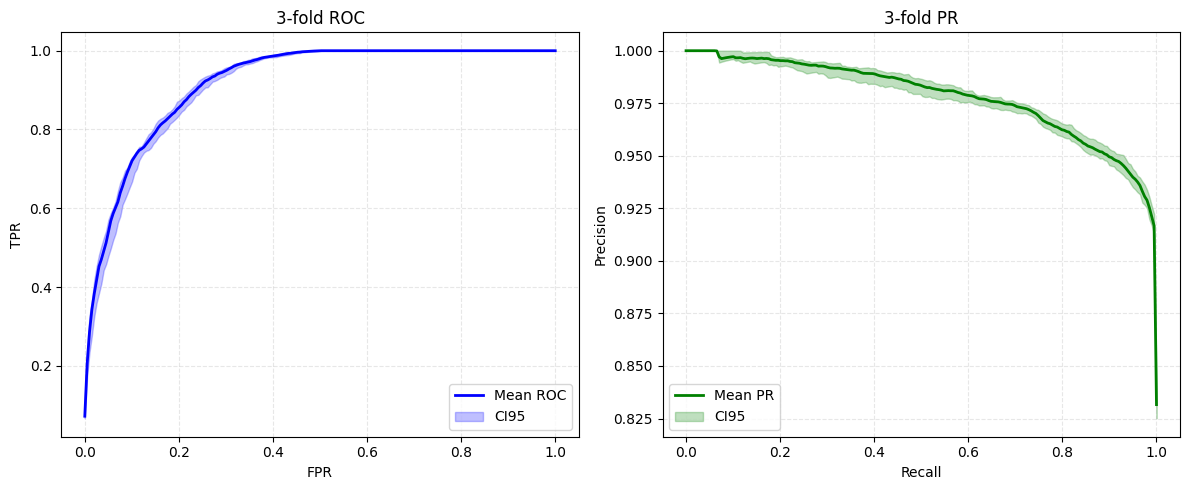

3-fold: AUROC=0.918, AUPRC=0.979


Bootstrap progress: 100%|██████████| 1500/1500 [00:00<00:00, 6563.23it/s]


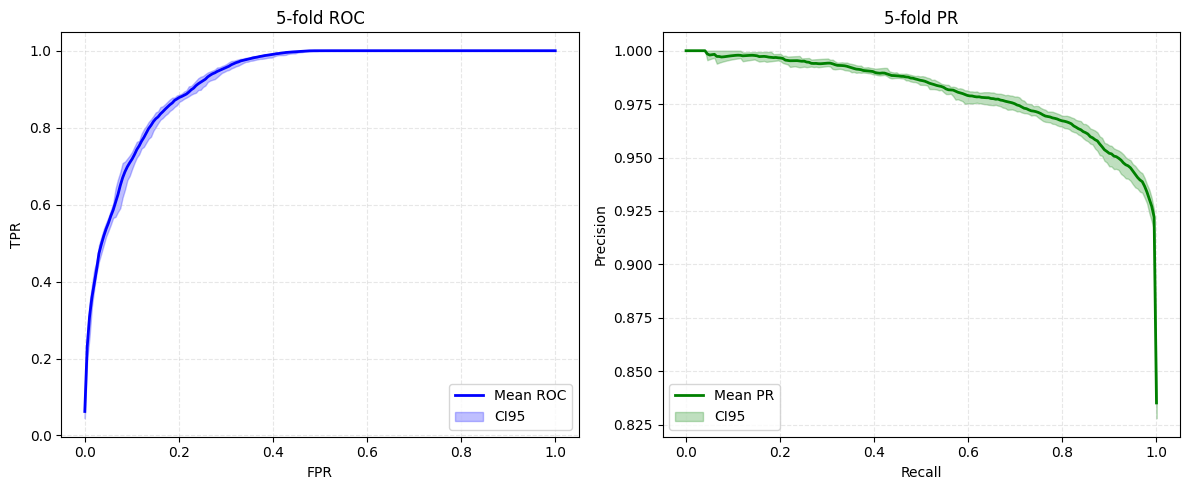

5-fold: AUROC=0.923, AUPRC=0.980


Bootstrap progress: 100%|██████████| 1500/1500 [00:00<00:00, 6044.35it/s]


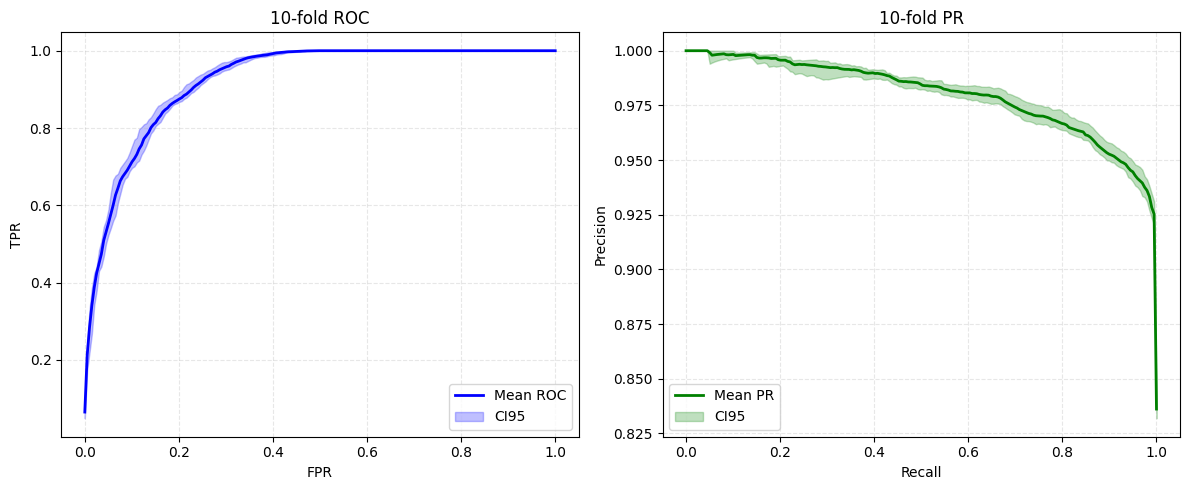

10-fold: AUROC=0.923, AUPRC=0.980


Bootstrap progress: 100%|██████████| 1500/1500 [00:00<00:00, 2749.48it/s]


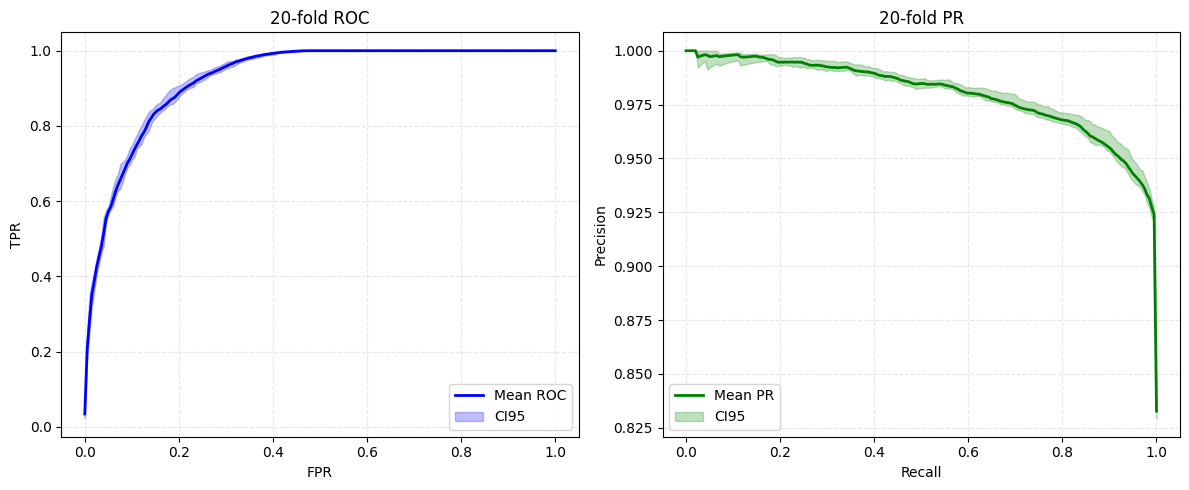

20-fold: AUROC=0.925, AUPRC=0.980


Bootstrap progress: 100%|██████████| 1500/1500 [00:00<00:00, 6248.04it/s]


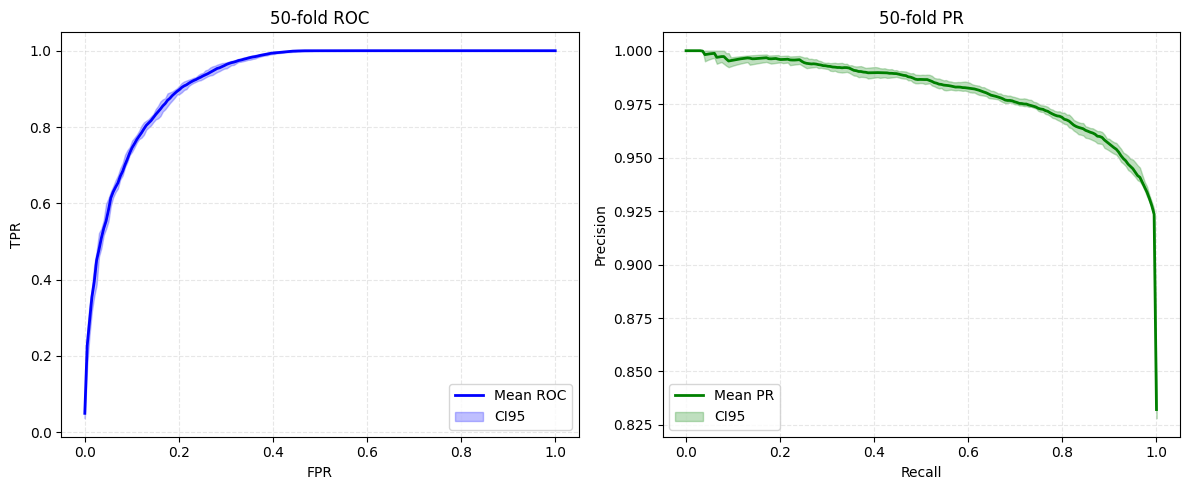

50-fold: AUROC=0.928, AUPRC=0.981


Bootstrap progress: 100%|██████████| 1500/1500 [00:00<00:00, 6200.59it/s]


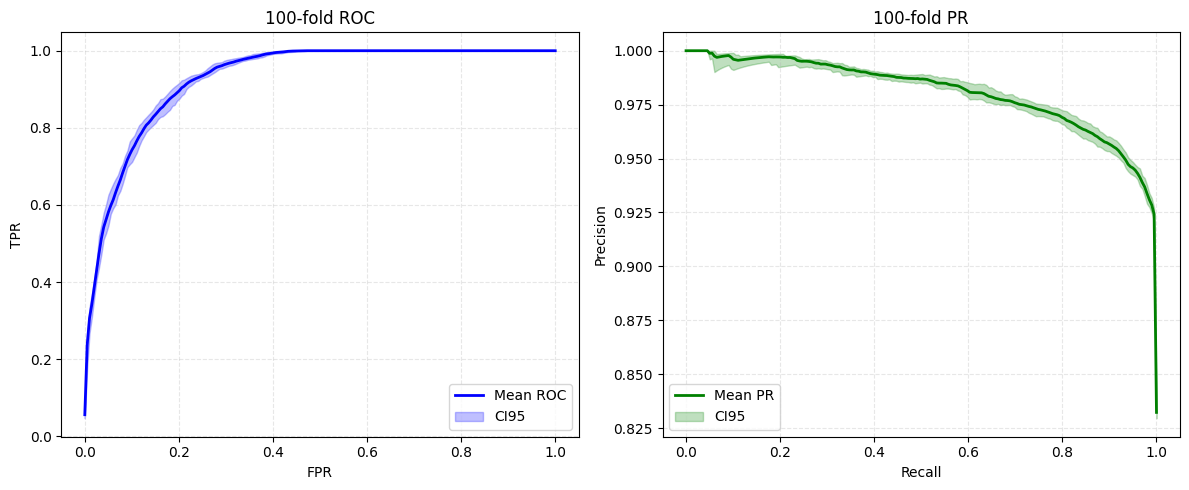

100-fold: AUROC=0.928, AUPRC=0.981


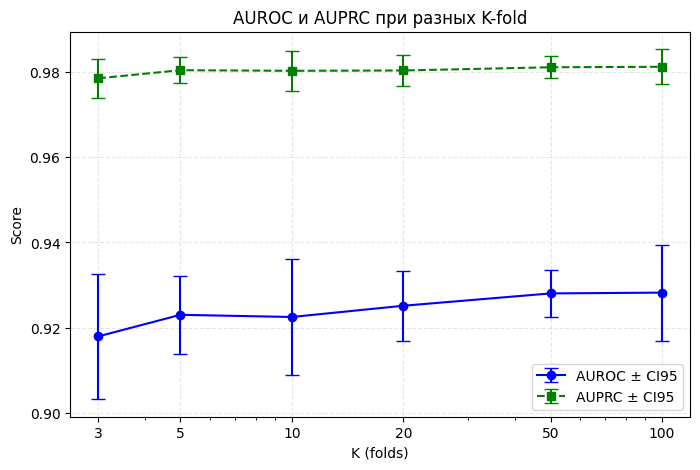

,folds,AUROC_mean,AUROC_CI95,AUPRC_mean,AUPRC_CI95
0,3,0.917973,"(0.9079419882685935, 0.9226873172965595)",0.978527,"(0.9759680306658729, 0.9805931068346351)"
1,5,0.923033,"(0.9169250821859161, 0.9260232747565784)",0.980422,"(0.9787868770525497, 0.9818345834011343)"
2,10,0.922522,"(0.9166525582334789, 0.9303424647226309)",0.980283,"(0.9774786609761126, 0.9822184982636845)"
3,20,0.925158,"(0.9228816745800148, 0.9311444565244643)",0.980355,"(0.9790815884662653, 0.9828094455898392)"
4,50,0.928052,"(0.9259377724889267, 0.9315184185236997)",0.981113,"(0.9803300462082951, 0.9829146274737541)"
5,100,0.928239,"(0.9226039364729225, 0.9338891447615347)",0.981221,"(0.978880273730854, 0.9830034084194871)"


In [43]:
# === Запуск задания 8 ===
df10 = oversampled_datasets['df10']
results_task8 = task8_kfold_roc_pr(df10, n_boot=1500)
results_task8

# [9] Multi-Feature LDA

In [44]:
def task9_features_roc(df, features_list=(2, 4, 8, 16), n_boot=500, random_state=42, n_jobs=-1):
    """
    Для df1 строит ROC-кривые с доверительными полосами при разном числе признаков (без PCA).
    Возвращает DataFrame со средними AUC и CI95 для каждого числа признаков.
    """
    X_full = df.drop(columns=['species']).values
    y = df['species'].values
    y_bin = (y == 0).astype(int)

    plt.figure(figsize=(8,6))
    colors = ['blue', 'green', 'orange', 'red']

    results_list = []

    for i, n_feat in enumerate(features_list):
        X = X_full[:, :n_feat]

        lda = LinearDiscriminantAnalysis()
        lda.fit(X, y_bin)
        try:
            y_score = lda.decision_function(X)
        except:
            y_score = lda.predict_proba(X)[:, 1]

        roc_res = bootstrap_curve(
            y_bin, y_score, n_boot=n_boot,
            curve_type='roc', random_state=random_state, n_jobs=n_jobs
        )

        auc_mean = np.mean(roc_res['aucs_boot'])
        auc_ci = (roc_res['auc_ci'][0], roc_res['auc_ci'][1])
        results_list.append({
            'n_features': n_feat,
            'AUROC_mean': auc_mean,
            'AUROC_CI95': auc_ci
        })

        plt.plot(
            roc_res['grid'],
            np.mean(roc_res['tprs_boot'], axis=0),
            color=colors[i % len(colors)],
            lw=2,
            label=f'{n_feat} features (AUC={auc_mean:.3f})'
        )
        plt.fill_between(
            roc_res['grid'],
            roc_res['tpr_lower'], roc_res['tpr_upper'],
            color=colors[i % len(colors)],
            alpha=0.2
        )

    plt.plot([0,1],[0,1],'--',color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-кривые с CI95 для разных чисел признаков (df1)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return pd.DataFrame(results_list)


Bootstrap progress: 100%|██████████| 1500/1500 [00:00<00:00, 12256.62it/s]


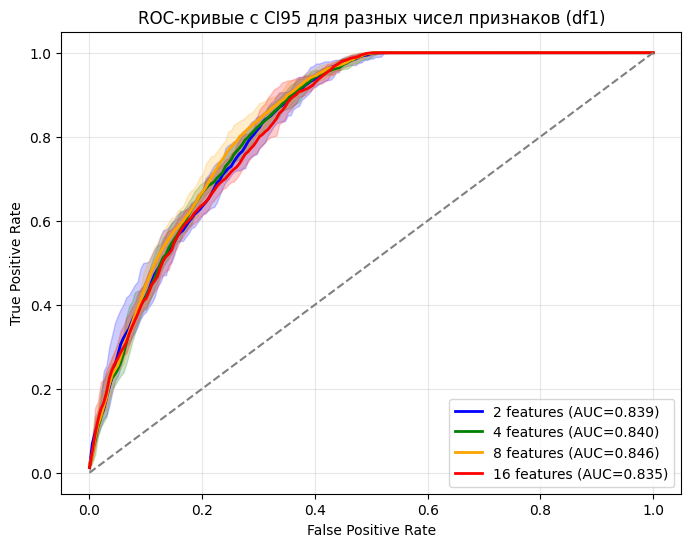

,n_features,AUROC_mean,AUROC_CI95
0,2,0.838622,"(0.8285217842741124, 0.8599003095639921)"
1,4,0.839975,"(0.8353653383343662, 0.8517507266578173)"
2,8,0.845648,"(0.8359410141691299, 0.8586179703535696)"
3,16,0.835305,"(0.8282600444994217, 0.8526035445907311)"


In [45]:
# Запуск
df9_results = task9_features_roc(df1, n_boot=1500)
df9_results